In [1]:
#models
# r-train-models conda environment
library(plyr)
library(dplyr)
library(tidyverse)
library(caret)
library(recipes)
library(pROC)
library(devtools)
library(here)
library(rlucas)
library(reticulate)
#library(gbm)
library(cowplot)
library(FSelectorRcpp)
#library(colino)
#library(janitor)

dir.create("../../outputs/Fig2", recursive = TRUE, showWarnings = FALSE)
dir.create("../../outputs/Fig2/Fig2-protein_boxplots/", recursive = TRUE, showWarnings = FALSE)




Attaching package: ‘dplyr’


The following objects are masked from ‘package:plyr’:

    arrange, count, desc, failwith, id, mutate, rename, summarise,
    summarize


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.2     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.2.1
✔ purrr     1.1.0     ✔ tidyr     1.3.1
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::arrange()   masks plyr::arrange()
✖ purrr::compact()   masks plyr::compact()
✖ dplyr::count()     masks plyr::count()
✖ dplyr::desc()      masks plyr::desc()
✖ dplyr::failwith()  masks plyr::failwith()
✖ dp

## Load data

In [2]:
lucas_df <- read.csv("../../data/lucas_df_with_pcs.csv")

lucas_df <- lucas_df %>%
  mutate(clinical_CEA = log2(clinical_CEA + 1))
lucas_df <- lucas_df %>% select(-olink_CEA)
merged_df <- lucas_df

## Figure 2a: Odds Ratio Volcano Plot

In [3]:
# =========================
# Dependencies
# =========================
library(tidyverse)
library(broom)
library(ggrepel)

# =========================
# Helper: compute ENT via PCA (95% variance by default)
# =========================
.compute_ENT <- function(df, feature_cols, var_explained = 0.95, min_n_per_feature = 10) {
  X <- df %>% select(all_of(feature_cols))
  keep <- names(X)[map_lgl(X, ~ sum(!is.na(.x)) >= min_n_per_feature && sd(.x, na.rm = TRUE) > 0)]
  if (length(keep) == 0) return(list(ENT = NA_integer_, used_cols = character(0)))

  X <- X %>% select(all_of(keep))
  Ximp <- X %>% mutate(across(everything(), ~ ifelse(is.na(.x), median(.x, na.rm = TRUE), .x)))
  pca <- prcomp(Ximp, center = TRUE, scale. = TRUE)
  ve  <- (pca$sdev^2) / sum(pca$sdev^2)
  ENT <- which(cumsum(ve) >= var_explained)[1]
  list(ENT = ENT, used_cols = keep)
}

# =========================
# Main: run_protein_lr
# =========================
run_protein_lr <- function(
  df,
  outcome_col = "type",                          # expects "cancer" vs not
  features_regex = "^olink_",                    # which features to scan
  include_clinical_CEA = TRUE,                   # include clinical_CEA (log2)
  covariates = c("clinical_age", "Sex", "clinical_smokingstatus"),
  correction = c("FDR", "ENT", "NONE"),          # multiple-testing method
  fdr_method = "BH",
  fdr_level = 0.05,                              # primary q-value threshold (stricter)
  fdr_level_secondary = NULL,                    # secondary threshold (more lenient, e.g., 0.10)
  ent_alpha = 0.05,                              # alpha used in ENT (alpha/ENT)
  ent_var_explained = 0.95,                      # % variance for ENT
  p_level = 0.05,                                # raw-p cutoff when NONE
  min_n = 20                                     # guardrail for complete cases
) {
  correction <- match.arg(correction)

  # ---- Prepare dataframe ----
  stopifnot(outcome_col %in% names(df))
  if (!all(covariates %in% names(df))) {
    missing_covs <- covariates[!covariates %in% names(df)]
    stop("These covariates were not found in df: ",
         paste(missing_covs, collapse = ", "))
  }

  dat <- df %>% mutate(type_bin = ifelse(.data[[outcome_col]] == "cancer", 1L, 0L))

  if ("Sex" %in% names(dat)) {
    dat <- dat %>% mutate(Sex = factor(Sex))
  }
  if ("clinical_smokingstatus" %in% names(dat)) {
    dat <- dat %>% mutate(
      clinical_smokingstatus = factor(clinical_smokingstatus,
                                      levels = c("never", "former", "current"),
                                      ordered = FALSE)
    )
  }

  # Identify feature columns
  feature_cols <- names(dat)[grepl(features_regex, names(dat))]
  if (include_clinical_CEA && "clinical_CEA" %in% names(dat)) {
    feature_cols <- c("clinical_CEA", feature_cols)
  }
  if (length(feature_cols) == 0) stop("No feature columns found.")

  # ---- Per-feature adjusted LR (OR per 1 SD) ----
  fit_one_adj <- function(d, feature, covs, min_n) {
    needed <- c("type_bin", covs, feature)
    d2 <- d %>% select(all_of(needed)) %>% drop_na()

    if (nrow(d2) < min_n || sd(d2[[feature]], na.rm = TRUE) == 0) {
      return(tibble(
        feature = feature, estimate = NA_real_, std.error = NA_real_,
        statistic = NA_real_, p.value = NA_real_,
        odds_ratio_sd = NA_real_, conf.low = NA_real_, conf.high = NA_real_, n = nrow(d2)
      ))
    }

    rhs  <- c("scale(x)", covs)
    form <- as.formula(paste("type_bin ~", paste(rhs, collapse = " + ")))
    mdat <- d2 %>% mutate(x = .data[[feature]])

    fit <- suppressWarnings(glm(form, data = mdat, family = binomial()))
    tt  <- tidy(fit, conf.int = TRUE)

    if (!("term" %in% names(tt)) || !any(tt$term == "scale(x)")) {
      return(tibble(
        feature = feature, estimate = NA_real_, std.error = NA_real_,
        statistic = NA_real_, p.value = NA_real_,
        odds_ratio_sd = NA_real_, conf.low = NA_real_, conf.high = NA_real_, n = nrow(d2)
      ))
    }

    row <- tt %>% filter(term == "scale(x)") %>% slice(1)

    tibble(
      feature = feature,
      estimate = row$estimate,
      std.error = row$std.error,
      statistic = if ("statistic" %in% names(row)) row$statistic else NA_real_,
      p.value = row$p.value,
      odds_ratio_sd = exp(row$estimate),
      conf.low = exp(row$conf.low),
      conf.high = exp(row$conf.high),
      n = nrow(d2)
    )
  }

  results <- map_dfr(feature_cols, ~ fit_one_adj(dat, .x, covariates, min_n)) %>%
    mutate(
      display_label = case_when(
        .data$feature == "clinical_CEA" ~ "CEA (CEACAM5)",
        startsWith(.data$feature, "olink_")   ~ sub("^olink_", "", .data$feature),
        TRUE ~ .data$feature
      )
    )

  # ---- Multiple testing choices (FDR / ENT / NONE) ----
  ENT_out <- NULL
  if (correction == "FDR") {
    results <- results %>%
      mutate(
        q.value = p.adjust(p.value, method = fdr_method)
      )
    
    # Handle dual thresholds for FDR
    if (!is.null(fdr_level_secondary)) {
      # Ensure primary is stricter (smaller) than secondary
      primary_thresh <- min(fdr_level, fdr_level_secondary)
      secondary_thresh <- max(fdr_level, fdr_level_secondary)
      
      results <- results %>%
        mutate(
          sig_primary = !is.na(q.value) & q.value < primary_thresh,
          sig_secondary = !is.na(q.value) & q.value >= primary_thresh & q.value < secondary_thresh,
          sig_flag = sig_primary | sig_secondary,  # for backward compatibility
          yval = -log10(pmax(q.value, .Machine$double.xmin)),
          cutoff_y_primary = -log10(primary_thresh),
          cutoff_y_secondary = -log10(secondary_thresh),
          cutoff_y = cutoff_y_primary  # for backward compatibility
        )
    } else {
      results <- results %>%
        mutate(
          sig_primary = !is.na(q.value) & q.value < fdr_level,
          sig_secondary = FALSE,
          sig_flag = sig_primary,
          yval = -log10(pmax(q.value, .Machine$double.xmin)),
          cutoff_y = -log10(fdr_level),
          cutoff_y_primary = cutoff_y,
          cutoff_y_secondary = NA_real_
        )
    }
    y_label <- expression(-log[10](FDR))

  } else if (correction == "ENT") {
    ENT_out <- .compute_ENT(dat, feature_cols, var_explained = ent_var_explained)
    ENT_val <- ENT_out$ENT

    if (is.na(ENT_val)) {
      warning("ENT could not be computed (no valid features); falling back to NONE with raw p-values.")
      results <- results %>%
        mutate(
          sig_primary = !is.na(p.value) & p.value < p_level,
          sig_secondary = FALSE,
          sig_flag = sig_primary,
          yval = -log10(pmax(p.value, .Machine$double.xmin)),
          cutoff_y = -log10(p_level),
          cutoff_y_primary = cutoff_y,
          cutoff_y_secondary = NA_real_
        )
      y_label <- expression(-log[10](p))
      correction <- "NONE"

    } else {
      ent_threshold <- ent_alpha / ENT_val
      results <- results %>%
        mutate(
          ENT = ENT_val,
          ENT_threshold = ent_threshold,
          sig_primary = !is.na(p.value) & p.value < ent_threshold,
          sig_secondary = FALSE,
          sig_flag = sig_primary,
          yval = -log10(pmax(p.value, .Machine$double.xmin)),
          cutoff_y = -log10(ent_threshold),
          cutoff_y_primary = cutoff_y,
          cutoff_y_secondary = NA_real_
        )
      y_label <- expression(-log[10](p))
      ENT_out <- c(ENT = ENT_val, threshold = ent_threshold)
    }

  } else { # NONE
    results <- results %>%
      mutate(
        sig_primary = !is.na(p.value) & p.value < p_level,
        sig_secondary = FALSE,
        sig_flag = sig_primary,
        yval = -log10(pmax(p.value, .Machine$double.xmin)),
        cutoff_y = -log10(p_level),
        cutoff_y_primary = cutoff_y,
        cutoff_y_secondary = NA_real_
      )
    y_label <- expression(-log[10](p))
  }

  # ---- Build plotting data from results ----
  volcano_data <- results %>%
    mutate(
      direction = case_when(
        is.na(odds_ratio_sd) ~ NA_character_,
        odds_ratio_sd > 1 ~ "OR>1",
        TRUE ~ "OR<1"
      ),
      # Create group with three significance levels
      sig_level = case_when(
        sig_primary ~ "primary",
        sig_secondary ~ "secondary",
        TRUE ~ "ns"
      ),
      grp = paste0(direction, " ", sig_level)
    )

  # Colors for direction × significance (three levels now)
  volcano_pal <- c(
    # Primary (most significant) - dark colors
    "OR>1 primary" = "#CD5C5C",
    "OR<1 primary" = "#08519C",
    # Secondary (between thresholds) - dark colors (same as primary)
    "OR>1 secondary" = "#CD5C5C",
    "OR<1 secondary" = "#08519C",
    # Not significant - light colors
    "OR>1 ns" = "#FFA07A",
    "OR<1 ns" = "#9ECAE1"
  )

  # Axis breaks for gridlines: every 1 on log2(OR), every 2 on −log10
  x_vals  <- log2(volcano_data$odds_ratio_sd)
  x_min   <- floor(min(x_vals[is.finite(x_vals)], na.rm = TRUE))
  x_max   <- ceiling(max(x_vals[is.finite(x_vals)], na.rm = TRUE))
  x_breaks <- seq(x_min, x_max, by = 1)

  y_max   <- ceiling(max(volcano_data$yval, na.rm = TRUE))
  y_breaks <- seq(0, max(2, y_max), by = 2)

  # ---- Publication-style volcano plot ----
  volcano_plot <- ggplot(volcano_data, aes(x = log2(odds_ratio_sd), y = yval)) +
    # threshold & reference lines - primary threshold
    geom_hline(aes(yintercept = cutoff_y_primary), linetype = "dashed", color = "gray40", linewidth = 0.6)
  
  # Add secondary threshold line if it exists
  if (!is.null(fdr_level_secondary) && correction == "FDR") {
    volcano_plot <- volcano_plot +
      geom_hline(aes(yintercept = cutoff_y_secondary), linetype = "dotted", color = "gray60", linewidth = 0.6)
  }
  
  volcano_plot <- volcano_plot +
    geom_vline(xintercept = 0, linetype = "dotted", color = "gray50", linewidth = 0.7) +
    # base points
    geom_point(aes(color = grp), size = 6, alpha = 0.8, na.rm = TRUE) +
    # black ring around primary significant points only
    geom_point(
      data = dplyr::filter(volcano_data, sig_primary),
      aes(x = log2(odds_ratio_sd), y = yval),
      shape = 21, fill = NA, color = "black", stroke = 1.5, size = 6.5, inherit.aes = FALSE
    ) +
    # labels for primary AND secondary significant proteins
    geom_text_repel(
      data = dplyr::filter(volcano_data, sig_primary | sig_secondary),
      aes(label = display_label),
      size = 7,
      box.padding = 1.0,
      point.padding = 1.2,
      max.overlaps = Inf,
      segment.color = "gray45",
      segment.size = 0.35
    ) +
    # color mapping (legend removed in theme)
    scale_color_manual(
      values = volcano_pal,
      breaks = c("OR>1 primary", "OR>1 secondary", "OR>1 ns",
                 "OR<1 primary", "OR<1 secondary", "OR<1 ns"),
      labels = c("OR>1, primary", "OR>1, secondary", "OR>1, ns",
                 "OR<1, primary", "OR<1, secondary", "OR<1, ns")
    ) +
    # gridline control
    scale_x_continuous(
      breaks = x_breaks, labels = x_breaks,
      expand = expansion(mult = c(0.02, 0.05))
    ) +
    scale_y_continuous(
      breaks = y_breaks, limits = c(0, NA),
      expand = expansion(mult = c(0.02, 0.07))
    ) +
    labs(title = NULL, x = expression("log"[2]*"(OR) per S.D."), y = y_label) +
    # publication look: border, no background grid (only explicit threshold lines remain), no legend
    theme_bw(base_size = 18) +
    theme(
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      panel.border     = element_rect(color = "black", fill = NA, linewidth = 1.2),
      legend.position  = "none",
      axis.text  = element_text(size = 18),
      axis.title = element_text(size = 25, face = "bold"),
      plot.background  = element_rect(fill = "white", color = NA),
      plot.margin      = margin(12, 22, 10, 10)
    )

  out <- list(results = results, plot = volcano_plot, correction = correction)
  if (!is.null(ENT_out)) out$ENT <- ENT_out
  out
}

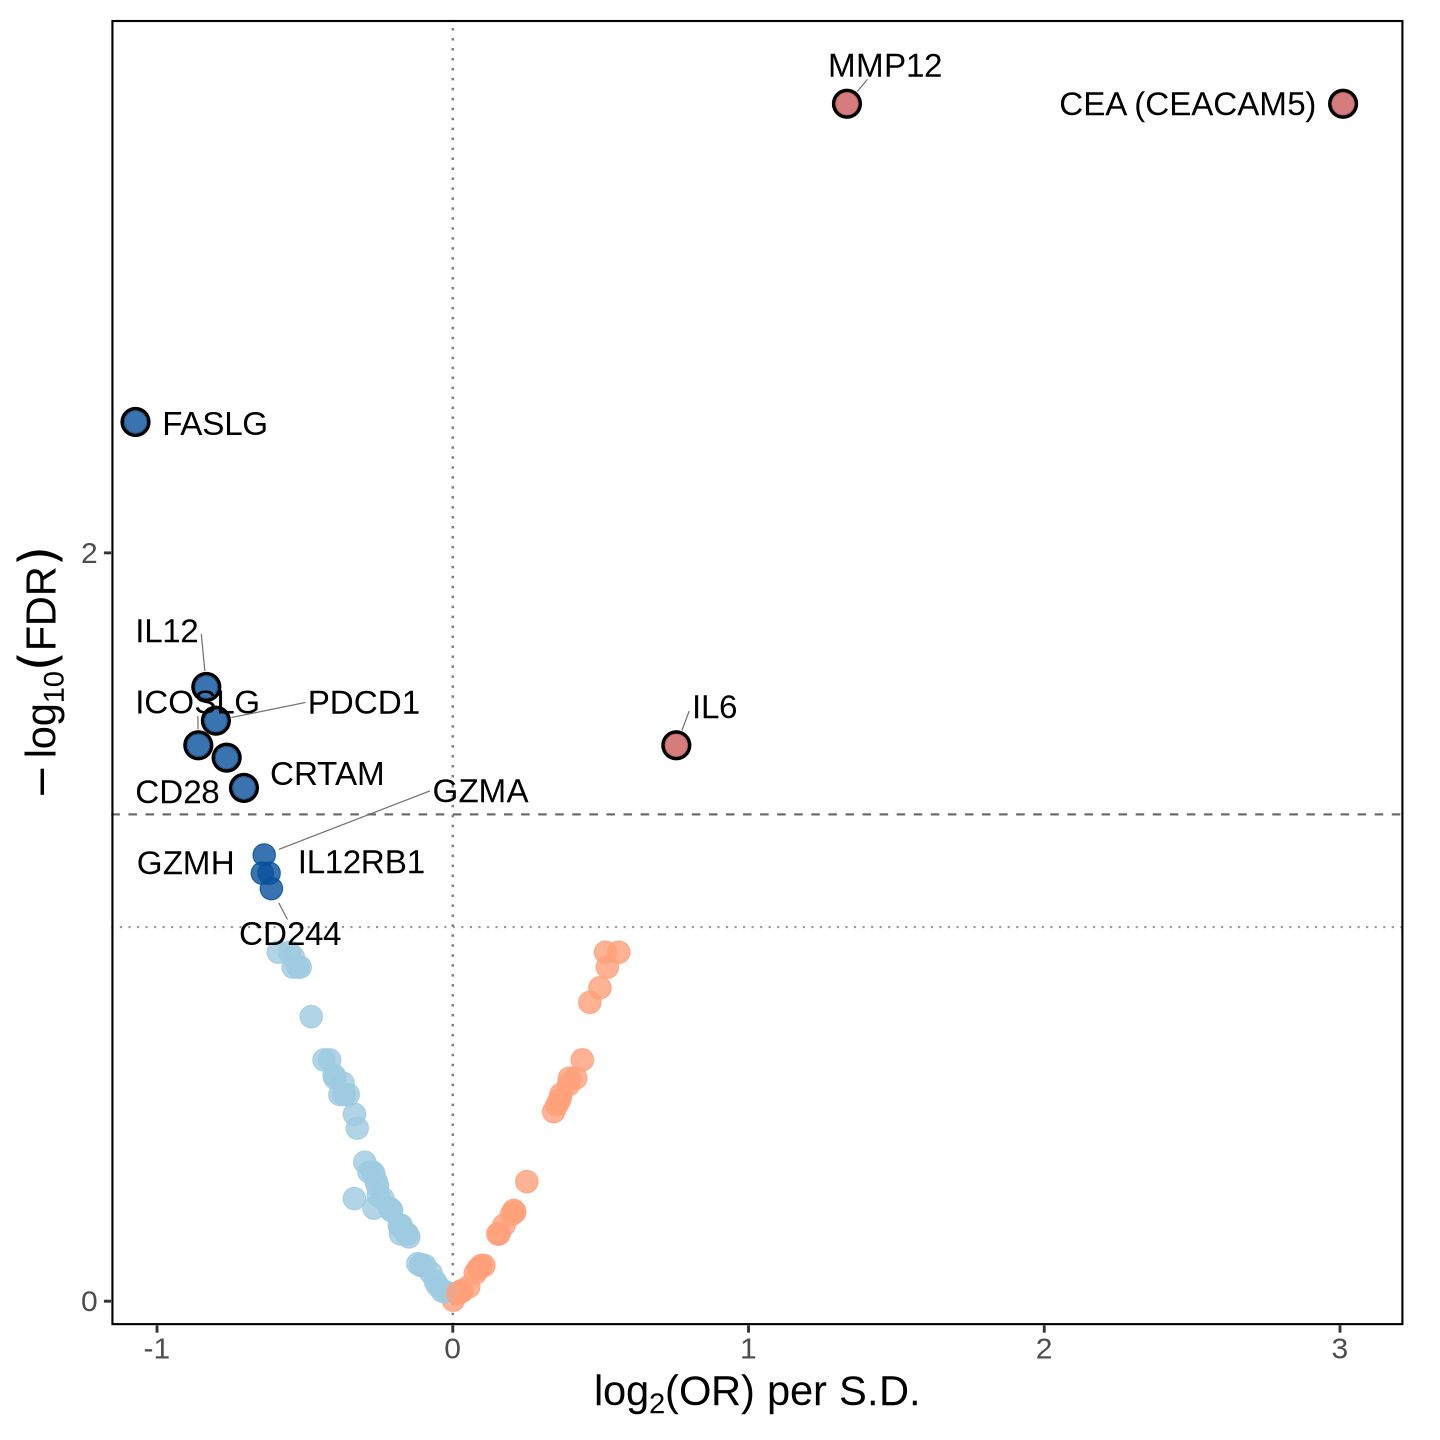

In [4]:
options(repr.plot.width = 12, repr.plot.height = 12)

# FDR (standard BH at 5%)
res_fdr <- run_protein_lr(
  df = lucas_df,
  outcome_col = "type",
  covariates = c("clinical_age", "clinical_sex", "clinical_smokingstatus"),
  correction = "FDR",
  fdr_level = 0.05,
  fdr_level_secondary = 0.10
)
res_fdr$plot

ggsave(
  filename = "../../outputs/Fig2/Fig2-Protein-Volcano-Plot-SD-FDR.png",   # or .pdf, .tiff, etc.
  plot     = res_fdr$plot,
  width    = 12,      # inches
  height   = 12,      # inches
  dpi      = 600, 
  bg       = "white",
    create.dir = TRUE
)


## Figure 2b: Proteomics across Stage

In [5]:
# Create df2 from FDR results
df2 <- res_fdr$results %>%
  mutate(
    Protein = case_when(
      feature == "clinical_CEA" ~ "CEA (CEACAM5)",
      str_starts(feature, "olink_") ~ str_remove(feature, "olink_"),
      TRUE ~ feature
    ),
    log10_pvalue = -log10(p.value)
  ) %>%
  arrange(p.value)

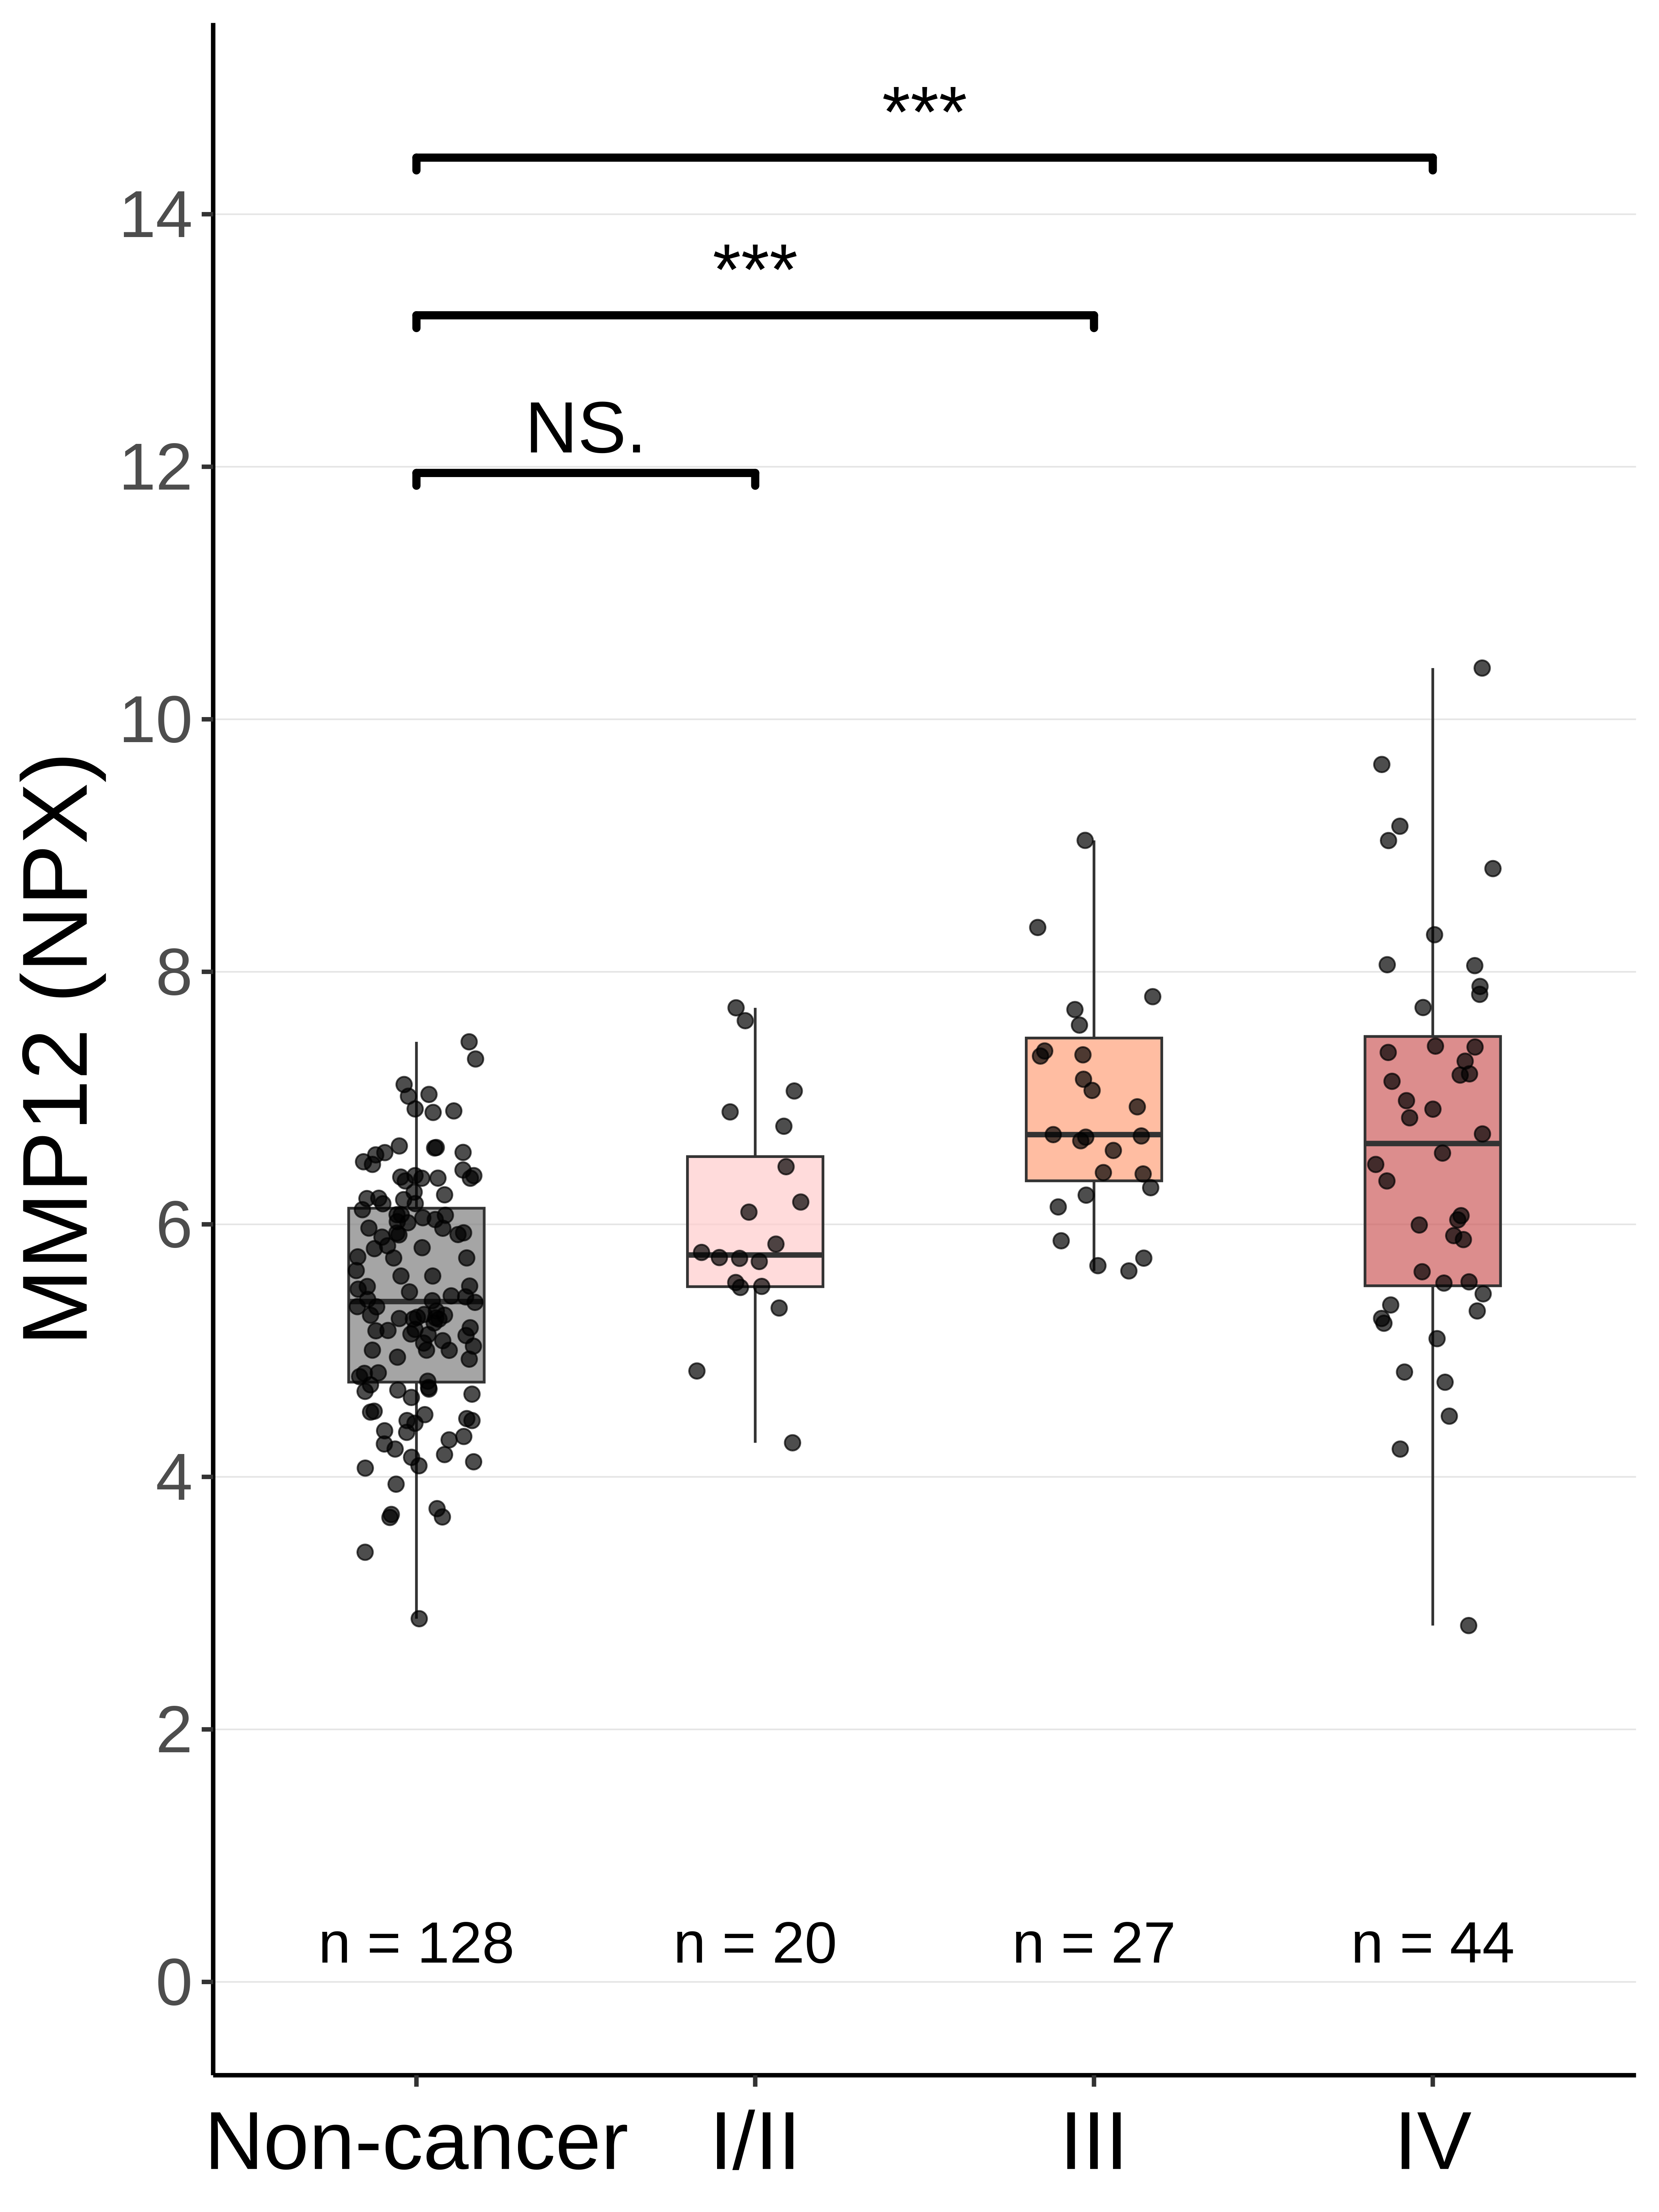

In [6]:
library(tidyverse)
library(ggsignif)

plot_biomarker_stage <- function(df, biomarker_col, biomarker_name, origin) {
  df <- df %>%
    mutate(
      StageGroup = case_when(
        is.na(Stage) ~ "Non-cancer",
        Stage %in% c("I", "II") ~ "I/II",
        Stage == "III" ~ "III",
        Stage == "IV" ~ "IV",
        TRUE ~ NA_character_
      ),
      StageGroup = factor(StageGroup, levels = c("Non-cancer", "I/II", "III", "IV"))
    ) %>%
    filter(!is.na(.data[[biomarker_col]]))
  
  if (origin == "Tumor Intrinsic") {
    fill_colors <- c(
      "Non-cancer" = "grey50",
      "I/II" = "#FFCCCB", 
      "III" = "#FFA07A", 
      "IV" = "#CD5C5C"
    )
  } else {
    fill_colors <- c(
      "Non-cancer" = "grey50",
      "I/II" = "#9ECAE1",
      "III" = "#4292C6",
      "IV" = "#08519C"
    )
  }

  comparisons <- list(
    c("Non-cancer", "I/II"),
    c("Non-cancer", "III"),
    c("Non-cancer", "IV")
  )
  
  # --- Identify outliers per group (1.5x IQR rule, same as boxplot uses) ---
  outlier_bounds <- df %>%
    group_by(StageGroup) %>%
    summarise(
      lower = quantile(.data[[biomarker_col]], 0.25) - 1.5 * IQR(.data[[biomarker_col]]),
      upper = quantile(.data[[biomarker_col]], 0.75) + 1.5 * IQR(.data[[biomarker_col]]),
      .groups = "drop"
    )
  
  # Non-outlier points only — used for jitter layer
  df_no_outliers <- df %>%
    left_join(outlier_bounds, by = "StageGroup") %>%
    filter(.data[[biomarker_col]] >= lower & .data[[biomarker_col]] <= upper)

  # Zoom ceiling based on the non-outlier data
  zoom_max <- max(df_no_outliers[[biomarker_col]], na.rm = TRUE)
  y_positions <- zoom_max * c(1.10, 1.22, 1.34)
  
  p <- ggplot(df, aes(x = StageGroup, y = .data[[biomarker_col]], fill = StageGroup)) +
    geom_boxplot(alpha = 0.7, outlier.shape = NA, width = 0.4) +  # outlier.shape = NA hides default outlier dots
    geom_jitter(
      data = df_no_outliers,   # ← only non-outlier points plotted
      width = 0.18, size = 2.5, alpha = 0.7
    ) +
    scale_fill_manual(values = fill_colors) +
    labs(x = NULL, y = paste0(biomarker_name, " (NPX)")) +
    scale_y_continuous(breaks = scales::pretty_breaks(n = 6)) +
    coord_cartesian(ylim = c(0, zoom_max * 1.42)) +
    theme_classic(base_size = 18) +
    theme(
      plot.title         = element_text(hjust = 0.5, size = 20, face = "bold"),
      axis.title.y       = element_text(size = 36),
      axis.text.x        = element_text(size = 32, color = "black", margin = margin(t = 10)),
      axis.text.y        = element_text(size = 26),
      panel.grid.major.y = element_line(color = "grey90", linewidth = 0.3),
      legend.position    = "none"
    ) +
    geom_signif(
      comparisons      = comparisons,
      y_position       = y_positions,
      map_signif_level = TRUE,
      test             = "t.test",
      size             = 1.5,
      textsize         = 10,
      tip_length       = 0.01
    )
  
  # Sample sizes from full data (not filtered)
  sample_sizes <- df %>%
    group_by(StageGroup) %>%
    summarise(n = n(), .groups = "drop") %>%
    arrange(factor(StageGroup, levels = levels(df$StageGroup)))
  
  label_ypos <- zoom_max * 0.03
  for (i in seq_len(nrow(sample_sizes))) {
    p <- p + annotate("text",
                      x     = i,
                      y     = label_ypos,
                      label = paste0("n = ", sample_sizes$n[i]),
                      size  = 8,
                      color = "black")
  }
  
  print(p)
}

options(repr.plot.width = 9, repr.plot.height = 12, repr.plot.res = 500)
plot_biomarker_stage(lucas_df, biomarker_col = "olink_MMP12", biomarker_name = "MMP12", origin = "Tumor Intrinsic")

In [7]:
save_all_plots <- function(merged_df, output_dir, biomarker_list, origin = "Tumor Intrinsic") {
  dir.create(output_dir, showWarnings = FALSE)
  
  for (biomarker_col in biomarker_list) {
    # Extract biomarker name from column (remove "olink_" prefix if present)
    biomarker_name <- gsub("^olink_", "", biomarker_col)
    
    safe_name <- gsub("[^a-zA-Z0-9_\\-]", "_", biomarker_name)
    plot_file <- file.path(output_dir, paste0(safe_name, ".png"))
    
    png(filename = plot_file, width = 9, height = 10, units = "in", res = 500)
    plot_biomarker_stage(merged_df, biomarker_col, biomarker_name, origin)
    dev.off()
  }
}

# Usage
my_biomarkers <- c("olink_FASLG", "olink_IL12", "olink_ICOSLG")

save_all_plots(merged_df, "../../outputs/Fig2/Fig2-protein_boxplots/", biomarker_list = my_biomarkers, origin = "Tumor Extrinsic")

my_biomarkers <- c("olink_MMP12", "olink_IL6", "clinical_CEA")

save_all_plots(merged_df, "../../outputs/Fig2/Fig2-protein_boxplots/", biomarker_list = my_biomarkers, origin = "Tumor Intrinsic")    

## Figure 2c: scRNA-Seq Heatmap

In [8]:
# Create df2 from FDR results
df2 <- res_fdr$results %>%
  mutate(
    Protein = case_when(
      feature == "clinical_CEA" ~ "CEA (CEACAM5)",
      str_starts(feature, "olink_") ~ str_remove(feature, "olink_"),
      TRUE ~ feature
    ),
    log10_pvalue = -log10(p.value)
  ) %>%
  arrange(p.value)

### Loading Transcriptomic Files
#### cancer_lung_filtered.tsv is derived from rna_cancer_sample.tsv.gz filtered for LUAD and LUSC

In [9]:
library(readr)
library(dplyr)

# Load data
sc_type_expr <- read_tsv("../../data/rna_single_cell_type.tsv")
sc_cluster_expr <- read_tsv("../../data/rna_single_cell_cluster.tsv")
cancer_expr <- read_tsv("../../data/cancer_lung_filtered.tsv") ## This is the 

# Summarize cancer expression by Gene and Cancer type
cancer_expr_summary <- cancer_expr %>%
  group_by(Gene, Cancer) %>%
  summarise(median_pTPM = median(pTPM, na.rm = TRUE), .groups = "drop")

# Get gene symbol mapping from sc_cluster_expr
gene_symbol_map <- sc_cluster_expr %>%
  select(Gene, `Gene name`) %>%
  distinct()

# Prepare cancer data to match sc_cluster structure
cancer_as_cells <- cancer_expr_summary %>%
  filter(Cancer %in% c("Lung Adenocarcinoma (TCGA)", "Lung Squamous Cell Carcinoma (TCGA)")) %>%
  mutate(
    Tissue = "Lung Cancer",
    `Cell type` = if_else(Cancer == "Lung Adenocarcinoma (TCGA)", "LUAD", "LUSC"),
    Cluster = if_else(Cancer == "Lung Adenocarcinoma (TCGA)", "c-1", "c-2"),
    nTPM = median_pTPM
  ) %>%
  left_join(gene_symbol_map, by = "Gene") %>%
  select(Gene, Tissue, Cluster, `Cell type`, nTPM, `Gene name`)

# Combine with single-cell cluster data
combined_cluster_expr <- bind_rows(
  sc_cluster_expr %>% select(Gene, Tissue, Cluster, `Cell type`, nTPM, `Gene name`),
  cancer_as_cells
)

Rows: 1626642 Columns: 4
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (3): Gene, Gene name, Cell type
dbl (1): nTPM

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 11185674 Columns: 7
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (5): Gene, Gene name, Tissue, Cluster, Cell type
dbl (2): Read count, nTPM

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 19693378 Columns: 4
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (3)

In [10]:
library(dplyr)
library(stringr)
library(biomaRt)
library(HGNChelper)

# Extract and clean protein symbols from df2
prot_df <- df2 %>%
  distinct(Protein) %>%
  mutate(
    candidate_upper = toupper(str_trim(
      if_else(str_detect(Protein, "\\(.+\\)"),
              str_match(Protein, "\\(([^)]+)\\)")[,2],
              Protein)
    ))
  )

# Fix symbols using HGNChelper
hgnc_fix <- checkGeneSymbols(prot_df$candidate_upper, unmapped.as.na = FALSE)
prot_df$suggested_symbol <- hgnc_fix$Suggested.Symbol

# Manual overrides for known problem symbols
manual_map <- c(
  "PDGF SUBUNIT B" = "PDGFB", "IFN-GAMMA" = "IFNG", "LAP TGF-BETA-1" = "TGFB1",

"IL12" = "IL12A", "IL-35" = "EBI3", "IL17C /// IL21 /// IL22" = "IL21",
  "MIC-A/B" = "MICA", "VEGFR-2" = "KDR", "IL-1 ALPHA" = "IL1A", "GAL-9" = "LGALS9",
  "CSF-1" = "CSF1", "IFN-BETA" = "IFNB1", "ANG-1" = "ANGPT1", "GAL-1" = "LGALS1"
)
names(manual_map) <- toupper(names(manual_map))

# Apply manual overrides
prot_df <- prot_df %>%
  mutate(suggested_symbol = coalesce(
    manual_map[toupper(suggested_symbol)],
    manual_map[candidate_upper],
    suggested_symbol
  ))

# Map to Ensembl via biomaRt
mart <- useEnsembl(biomart = "genes", dataset = "hsapiens_gene_ensembl")
map_A <- getBM(
  attributes = c("hgnc_symbol", "ensembl_gene_id", "gene_biotype"),
  filters = "hgnc_symbol",
  values = unique(prot_df$suggested_symbol),
  mart = mart
) %>% distinct()

unmapped_syms <- setdiff(unique(prot_df$suggested_symbol), unique(map_A$hgnc_symbol))

Please cite our software :) 
 
 Sehyun Oh et al. HGNChelper: identification and correction of invalid gene symbols for human and mouse. F1000Research 2020, 9:1493. DOI: https://doi.org/10.12688/f1000research.28033.1 
 
 Type `citation('HGNChelper')` for a BibTeX entry.

Maps last updated on: Sat Nov 16 10:35:32 2024

Warning message in checkGeneSymbols(prot_df$candidate_upper, unmapped.as.na = FALSE):
“x contains non-approved gene symbols”
Ensembl site unresponsive, trying asia mirror

Ensembl site unresponsive, trying useast mirror



In [11]:
library(dplyr)
library(stringr)

# Resolve duplicates: prefer exact match, protein_coding, valid ENSG
df2_mapped <- prot_df %>%
  left_join(map_A, by = c("suggested_symbol" = "hgnc_symbol")) %>%
  mutate(rank_choice = 
    (suggested_symbol != candidate_upper) +
    2L * (gene_biotype != "protein_coding") +
    (!str_detect(ensembl_gene_id, "^ENSG") | is.na(ensembl_gene_id))
  ) %>%
  group_by(Protein) %>%
  slice_min(rank_choice, n = 1, with_ties = FALSE) %>%
  ungroup() %>%
  dplyr::select(Protein, suggested_symbol, ensembl_gene_id, gene_biotype) %>%
  right_join(df2, by = "Protein") %>%
  rename(Gene = ensembl_gene_id)

# Clean combined_cluster_expr and match by ID or symbol
cc <- combined_cluster_expr %>%
  mutate(Gene_core = sub("\\.\\d+$", "", Gene))

ensg_genes <- unique(na.omit(df2_mapped$Gene))

# ID matches
id_matches <- cc %>%
  filter(Gene_core %in% ensg_genes) %>%
  mutate(.match_type = "id")

# Symbol matches for remaining proteins
remaining_symbols <- df2_mapped %>%
  filter(is.na(Gene) | !(Gene %in% id_matches$Gene_core)) %>%
  pull(suggested_symbol) %>% na.omit() %>% unique()

sym_matches <- cc %>%
  filter(`Gene name` %in% remaining_symbols, !(Gene_core %in% id_matches$Gene_core)) %>%
  mutate(.match_type = "symbol")

# Combine matches
combined_cluster_expr_filtered <- bind_rows(id_matches, sym_matches)

# Map match type back to df2
df2_final_mapped <- df2_mapped %>%
  left_join(
    combined_cluster_expr_filtered %>%
      dplyr::select(Gene_core, `Gene name`, .match_type) %>%
      distinct(),
    by = c("suggested_symbol" = "Gene name")
  ) %>%
  mutate(.match_type = coalesce(.match_type, "unmatched"))

In [12]:
library(dplyr)
library(stringr)

# 1) Top proteins by -log10(p)
top30 <- df2_final_mapped %>%
  arrange(desc(log10_pvalue)) %>%
  slice_head(n = 36)

top_ids   <- unique(na.omit(top30$Gene))
top_syms  <- unique(na.omit(top30$suggested_symbol))

# 2) Make a version-free Ensembl column in the expression table
cc <- combined_cluster_expr_filtered %>%
  mutate(Gene_core = sub("\\.\\d+$", "", Gene))

# 3) ID pass + symbol pass (keep union; prefer ID if both hit)
sig_combined_cluster_expr_filtered <- cc %>%
  filter(Gene_core %in% top_ids | `Gene name` %in% top_syms) %>%
  dplyr::select(-Gene_core)

# 4) Optional: see which of the top30 failed to match even after both passes
matched_ids   <- unique(sub("\\.\\d+$", "", sig_combined_cluster_expr_filtered$Gene))
matched_syms  <- unique(sig_combined_cluster_expr_filtered$`Gene name`)

unmatched_top <- top30 %>%
  filter(!(Gene %in% matched_ids) & !(suggested_symbol %in% matched_syms)) %>%
  dplyr::select(Protein, suggested_symbol, Gene, log10_pvalue)
#unmatched_top

### Heatmap Plotting 

In [13]:
library(readr)
library(dplyr)

blood_pea <- read_tsv("../../data/blood_pea_disease_de.tsv")
filtered_blood_pea <- blood_pea %>%
  filter(Disease == "Lung cancer")


Rows: 205674 Columns: 7
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (5): Gene, ENSG ID, Disease, Class, Control
dbl (2): logFC, p-value adjusted

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [14]:
# --- Modified heatmap_by_tissue to return gene_order alongside plot ---
heatmap_by_tissue <- function(df, tissue_types, tissue_labels = NULL, highlight_celltype_col = NULL) {
  
  if (is.null(tissue_labels)) tissue_labels <- tissue_types
  
  celltype_counts <- df %>%
    filter(Tissue %in% tissue_types) %>%
    group_by(Tissue) %>%
    summarise(n_celltypes = n_distinct(`Cell type`), .groups = "drop")
  
  min_wrap <- 10
  max_wrap <- 25
  celltype_counts <- celltype_counts %>%
    mutate(wrap_width = pmin(pmax(round(n_celltypes * 1.6), min_wrap), max_wrap))
  
  wrap_widths <- setNames(celltype_counts$wrap_width, celltype_counts$Tissue)
  
  tissue_labels_wrapped <- mapply(function(label, tissue) {
    str_wrap(label, width = wrap_widths[[tissue]])
  }, tissue_labels, tissue_types, USE.NAMES = FALSE)
  
  tissue_colors <- setNames(
    c("#e41a1c", "#208068", "#ffbe51", "blue", "#7570b3")[seq_along(tissue_types)],
    tissue_labels_wrapped
  )
  
  expr_breaks <- c(0, 25, 50, 75, 100)
  expr_labels <- c("0–25%", "25–50%", "50–75%", ">75%")
  
  stopifnot(all(c("Gene", "Tissue", "Cell type", "nTPM", "Gene name") %in% colnames(df)))
  
  df_filt <- df %>%
    filter(Tissue %in% tissue_types) %>%
    mutate(category = Tissue)
  
  tissue_lookup <- setNames(tissue_labels_wrapped, tissue_types)
  df_filt$category <- unname(tissue_lookup[df_filt$category])
  
  heatmap_mat <- df_filt %>%
    group_by(`Gene name`, `Cell type`, category) %>%
    summarise(median_expr = median(nTPM, na.rm = TRUE), .groups = 'drop')
  
  global_gene_expr <- heatmap_mat %>%
    group_by(`Gene name`) %>%
    summarise(global_sum = sum(median_expr, na.rm = TRUE), .groups = "drop")
  
  heatmap_mat_vicky <- heatmap_mat %>%
    left_join(global_gene_expr, by = "Gene name") %>%
    mutate(vicky_perc = 100 * median_expr / global_sum) %>%
    mutate(vicky_perc = ifelse(is.finite(vicky_perc), vicky_perc, NA_real_))
  
  lung_cancer_label <- tissue_lookup["Lung Cancer"]
  cancer <- heatmap_mat_vicky %>%
    filter(category == lung_cancer_label) %>%
    group_by(`Cell type`) %>%
    mutate(expr_perc = 100 * (vicky_perc - min(vicky_perc, na.rm = TRUE)) /
                      (max(vicky_perc, na.rm = TRUE) - min(vicky_perc, na.rm = TRUE))) %>%
    ungroup()
  
  non_cancer <- heatmap_mat_vicky %>%
    filter(category != lung_cancer_label) %>%
    mutate(expr_perc = vicky_perc)
  
  heatmap_mat2 <- bind_rows(non_cancer, cancer)
  
  heatmap_mat2_nodup <- heatmap_mat2 %>%
    mutate(celltype_col = paste(category, `Cell type`, sep = ":")) %>%
    group_by(`Gene name`, celltype_col, category, `Cell type`) %>%
    summarise(expr_perc = mean(expr_perc, na.rm = TRUE), .groups = "drop")
  
  expr_wide <- heatmap_mat2_nodup %>%
    dplyr::select(`Gene name`, celltype_col, expr_perc) %>%
    tidyr::pivot_wider(names_from = celltype_col, values_from = expr_perc)
  
  expr_mat <- as.data.frame(expr_wide)
  rownames(expr_mat) <- expr_mat$`Gene name`
  expr_mat <- expr_mat[, -1, drop = FALSE]
  expr_mat[is.na(expr_mat)] <- 0

  luad_cols <- grep("^Cancer:", colnames(expr_mat), value = TRUE)
  luad_expr <- rowMeans(expr_mat[, luad_cols, drop = FALSE], na.rm = TRUE)
  gene_order <- rownames(expr_mat)[order(luad_expr, decreasing = FALSE)]
  
  cell_dend <- hclust(dist(t(expr_mat)))
  cell_order <- colnames(expr_mat)[cell_dend$order]
  
  interpolate_color <- function(base_color, value_0_100) {
    enhanced_perc <- sqrt(value_0_100 / 100) * 100
    enhanced_perc[is.na(enhanced_perc)] <- 0
    rgb1 <- col2rgb(base_color) / 255
    rgb_final <- 1 + (rgb1 - 1) * (enhanced_perc / 100)
    rgb(t(rgb_final))
  }
  
  tissue_colors_wrapped <- setNames(
    c("#e41a1c", "#208068", "#ffbe51", "blue", "#7570b3")[seq_along(tissue_types)],
    tissue_labels_wrapped
  )
  
  tissue_colors_unwrapped <- setNames(
    c("#e41a1c", "#208068", "#ffbe51", "blue", "#7570b3")[seq_along(tissue_types)],
    tissue_labels
  )
  
  wrapped_to_unwrapped <- setNames(tissue_labels, tissue_labels_wrapped)
  
  heatmap_mat2_nodup$tile_col <- mapply(
    interpolate_color,
    tissue_colors_wrapped[as.character(heatmap_mat2_nodup$category)],
    heatmap_mat2_nodup$expr_perc
  )
  
  heatmap_mat2_nodup$expr_bin <- cut(heatmap_mat2_nodup$expr_perc,
                                     breaks = expr_breaks, labels = expr_labels, include.lowest = TRUE)
  
  heatmap_mat2_nodup <- heatmap_mat2_nodup %>%
    mutate(
      `Gene name` = factor(`Gene name`, levels = gene_order),
      `Cell type` = factor(`Cell type`, levels = unique(sub(".*:", "", cell_order))),
      category = factor(category, levels = tissue_labels_wrapped)
    )
  
  heatmap_mat2_nodup <- heatmap_mat2_nodup %>%
    mutate(tissue_unwrapped = wrapped_to_unwrapped[as.character(category)])
  
  if (!is.null(highlight_celltype_col)) {
    heatmap_mat2_nodup <- heatmap_mat2_nodup %>%
      mutate(highlight = ifelse(celltype_col == highlight_celltype_col, "highlight", "normal"))
  } else {
    heatmap_mat2_nodup$highlight <- "normal"
  }
  
  # Create dummy data for grayscale expression legend
  legend_df <- data.frame(
    expr_level = seq(0, 100, length.out = 100),
    y = 1
  )
  
  # Create the grayscale expression intensity legend as a separate plot
  expr_legend_plot <- ggplot(legend_df, aes(x = expr_level, y = y, fill = expr_level)) +
    geom_tile() +
    scale_fill_gradient(
      low = "white",
      high = "black",
      name = "RNA Expression\nIntensity (%)",
      breaks = c(0, 25, 50, 75, 100),
      labels = c("0%", "25%", "50%", "75%", "100%"),
      guide = guide_colorbar(
        barwidth = 1.2,
        barheight = 8,
        title.position = "top",
        title.hjust = 0.5,
        frame.colour = "black",
        ticks.colour = "black",
        ticks.linewidth = 0.5
      )
    ) +
    theme_void() +
    theme(
      legend.position = "right",
      legend.text = element_text(size = 11),
      legend.title = element_text(size = 12, face = "bold")
    )
  
  # Extract just the legend from the plot
  library(cowplot)
  expr_legend_grob <- get_legend(expr_legend_plot)
  
  heatmap_plot <- ggplot(heatmap_mat2_nodup,
                         aes(x = `Cell type`, y = `Gene name`, fill = tile_col)) +
    geom_tile(aes(color = category), size = 1) +
    geom_tile(data = subset(heatmap_mat2_nodup, highlight == "highlight"),
              fill = NA, color = "yellow", size = 2.5) +
    scale_fill_identity(guide = 'none') +
    scale_color_manual(
      values = tissue_colors_wrapped,
      name = "Tissue Type",
      guide = guide_legend(
        override.aes = list(fill = "white", color = tissue_colors_wrapped, size = 1.5),
        title.position = "top",
        title.hjust = 0.5,
        keywidth = 1.2,
        keyheight = 1.2
      )
    ) +
    theme_minimal(base_size = 13) +
    theme(
      legend.position = "right",
      legend.box = "vertical",
      legend.spacing = unit(0.3, "cm"),
      legend.margin = margin(0, 0, 0, 10),
      legend.text = element_text(size = 11),
      legend.title = element_text(size = 12, face = "bold"),
      panel.grid = element_blank(),
      axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size=13),
      axis.text.y = element_text(size = 13),
      axis.title.x = element_text(size=15, margin = margin(t = 20)),
      axis.title.y = element_text(size=15),
      strip.background = element_blank(),
      strip.text.x = element_text(size=15),
      plot.margin = margin(5, 5, 5, 5, "pt"), 
      panel.spacing.x = grid::unit(8, "pt")
    ) +
    labs(
      x = "Cell type",
      y = "Gene (nPM), Tissue (Human Protein Atlas)",
      title = ""
    ) +
    facet_grid(. ~ category, scales = "free_x", space = "free_x", switch = "x")
  
  return(list(
    plot = heatmap_plot, 
    gene_order = gene_order, 
    data = heatmap_mat2_nodup, 
    tissue_colors = tissue_colors_unwrapped,
    wrapped_to_unwrapped = wrapped_to_unwrapped,
    expr_legend = expr_legend_grob  # Return the expression legend grob
  ))
}

generate_combined_expression_plot <- function(
  df,                            
  expr_df,
  tumor_extrinsic = NULL,
  lung_parenchyma_intrinsic = NULL,
  extrinsic = NULL,
  tissue_types,
  tissue_labels = NULL,
  protein_to_gene_map = NULL,
  filtered_blood_pea = NULL,
  pea_sig_thresh = 0.05,
  size_cap_neglog10 = 10,
  size_range = c(1.8, 6)
) {

  library(ggplot2)
  library(dplyr)
  library(tidyr)
  library(ggnewscale)
  library(patchwork)
  library(stringr)
  library(scales)
  library(cowplot)
  library(grid)

  if (is.null(tissue_labels)) tissue_labels <- tissue_types

  # ---------------------------------------------------------------
  # 1. HEATMAP + EXTRACT ORDER + DATA
  # ---------------------------------------------------------------
  heatmap_res <- heatmap_by_tissue(
    expr_df,
    tissue_types = tissue_types,
    tissue_labels = tissue_labels
  )

  heat_data  <- heatmap_res$data
  heatmap_plot <- heatmap_res$plot
  expr_legend <- heatmap_res$expr_legend


  # ---------------------------------------------------------------
  # 2. COMPUTE INTRINSIC & EXTRINSIC
  # ---------------------------------------------------------------
  compute_intrinsic_extrinsic <- function(heatmap_data, cancer_label = "Cancer") {

    df2 <- heatmap_data %>%
      dplyr::select(`Gene name`, category, expr_perc)

    intrinsic_df <- df2 %>%
      filter(category == cancer_label) %>%
      group_by(`Gene name`) %>%
      summarise(
        `Tumor Intrinsic` = mean(expr_perc, na.rm = TRUE),
        .groups = "drop"
      )

    extrinsic_df <- df2 %>%
      filter(category != cancer_label) %>%
      group_by(`Gene name`) %>%
      summarise(
        `Tumor Extrinsic` = max(expr_perc, na.rm = TRUE),
        .groups = "drop"
      )

    full <- intrinsic_df %>%
      full_join(extrinsic_df, by = "Gene name") %>%
      mutate(
        `Tumor Intrinsic` = ifelse(is.na(`Tumor Intrinsic`), 0, `Tumor Intrinsic`),
        `Tumor Extrinsic` = ifelse(is.na(`Tumor Extrinsic`), 0, `Tumor Extrinsic`)
      )

    return(full)
  }

  summary_df <- compute_intrinsic_extrinsic(heatmap_res$data, cancer_label = "Cancer")


  # ---------------------------------------------------------------
  # 3. LOLLIPOP RANKING (determines row order)
  # ---------------------------------------------------------------
  lolli_df <- df %>%
    mutate(
      log2_OR = abs(log2(odds_ratio_sd)),
      DisplayGene = suggested_symbol
    ) %>%
    filter(DisplayGene %in% summary_df$`Gene name`)

  lolli_df <- lolli_df %>%
    left_join(summary_df, by = c("DisplayGene" = "Gene name")) %>%
    mutate(
      blue_dominant = `Tumor Extrinsic` > `Tumor Intrinsic`,
      lolli_color = ifelse(blue_dominant, "blue", "red")
    )

  gene_order <- lolli_df %>%
    arrange(log2_OR) %>%
    pull(DisplayGene)


  # ---------------------------------------------------------------
  # 4. MIDDLE PANEL: Intrinsic / Extrinsic Dotplot WITH GRADIENT
  # ---------------------------------------------------------------
  make_intrinsic_extrinsic_dotplot <- function(summary_df, gene_order) {
    
    long_df <- summary_df %>%
      rename(DisplayGene = `Gene name`) %>%
      pivot_longer(
        cols = c("Tumor Intrinsic", "Tumor Extrinsic"),
        names_to = "Category",
        values_to = "Value"
      ) %>%
      mutate(
        DisplayGene = factor(DisplayGene, levels = gene_order),
        Category = factor(Category, levels = c("Tumor Intrinsic", "Tumor Extrinsic"))
      )
    
    ggplot(long_df, aes(x = Category, y = DisplayGene)) +
      # Tumor Intrinsic Gradient (red)
      geom_point(
        data = subset(long_df, Category == "Tumor Intrinsic"),
        aes(size = Value, fill = Value),
        shape = 21, color = "black", stroke = 0.45
      ) +
      scale_fill_gradient(
        low = "#FDE0DD", high = "#A50F15",
        name = "Tumor Intrinsic\nExpression (%)",
        guide = guide_colorbar(
          order = 1,
          barwidth = 1,
          barheight = 8,
          title.position = "top",
          title.hjust = 0.5
        )
      ) +
      
      ggnewscale::new_scale_fill() +
      
      # Tumor Extrinsic Gradient (blue)
      geom_point(
        data = subset(long_df, Category == "Tumor Extrinsic"),
        aes(size = Value, fill = Value),
        shape = 21, color = "black", stroke = 0.45
      ) +
      scale_fill_gradient(
        low = "#DEEBF7", high = "#08519C",
        name = "Tumor Extrinsic\nExpression (%)",
        guide = guide_colorbar(
          order = 2,
          barwidth = 1,
          barheight = 8,
          title.position = "top",
          title.hjust = 0.5
        )
      ) +
      
      scale_size_continuous(
        range = c(2.2, 8),
        name = "Expression\nLevel (%)",
        guide = guide_legend(
          order = 3,
          title.position = "top",
          title.hjust = 0.5,
          override.aes = list(fill = "grey70")
        )
      ) +
      scale_y_discrete(position = "right") +
      
      labs(
        x = "Source",
        y = "Protein (Circulating Levels), Plasma (LUCAS Cohort)"
      ) +
      
      theme_minimal(base_size = 13) +
      theme(
        axis.text.x = element_text(size = 14, angle = 45, hjust = 1),
        axis.text.y.right = element_text(size = 13),
        axis.title.x = element_text(size = 16, margin = margin(t = 10)),
        axis.title.y.right = element_text(size = 15, margin = margin(l = 10), angle = 90),
        panel.grid = element_blank(),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 0.6),
        legend.position = "right",
        legend.box = "vertical",
        legend.text = element_text(size = 10),
        legend.title = element_text(size = 11, face = "bold"),
        plot.margin = margin(10, 10, 10, 10)
      )
  }

  intrinsic_extrinsic_plot <- make_intrinsic_extrinsic_dotplot(summary_df, gene_order)


  # ---------------------------------------------------------------
  # 5. RIGHT PANEL: LOLLIPOP
  # ---------------------------------------------------------------
  make_lollipop_plot <- function(lolli_df, gene_order) {

    lolli_df$DisplayGene <- factor(lolli_df$DisplayGene, levels = gene_order)

    ggplot(lolli_df, aes(y = DisplayGene, x = log2_OR)) +
      geom_segment(aes(x = 0, xend = log2_OR,
                       y = DisplayGene, yend = DisplayGene),
                   color = "grey85", linewidth = 0.6) +
      geom_point(aes(color = lolli_color), size = 3.2, stroke = 0.5) +
      scale_color_manual(
        values = c("red" = "#A50F15", "blue" = "#08519C"),
        name = "Dominant Source",
        labels = c("red" = "Tumor Intrinsic", "blue" = "Tumor Extrinsic"),
        guide = guide_legend(
          title.position = "top",
          title.hjust = 0.5,
          override.aes = list(size = 4)
        )
      ) +
      theme_classic(base_size = 13) +
      theme(
        axis.text.y = element_blank(),
        axis.title.y = element_blank(),
        axis.text.x = element_text(size = 13, color = "black"),
        axis.title.x = element_text(size = 15),
        panel.border = element_rect(color="black", fill=NA, linewidth=0.6),
        panel.grid.major.y = element_line(color = "grey90", linewidth = 0.3),
        axis.ticks.y = element_blank(),
        legend.position = "right",
        legend.text = element_text(size = 11),
        legend.title = element_text(size = 12, face = "bold"),
        plot.margin = margin(10,20,10,10)
      ) +
      labs(x = expression("Effect size, |log"[2]*"(OR)|"))
  }

  right_lolli <- make_lollipop_plot(lolli_df, gene_order)


  # ---------------------------------------------------------------
  # 6. ALIGN HEATMAP ROW ORDER TO LOLLIPOP GENE ORDER
  # ---------------------------------------------------------------
  heatmap_plot_aligned <- heatmap_plot +
    scale_y_discrete(limits = gene_order)
  
  # ---------------------------------------------------------------
  # 7. FINAL 3-PANEL COMPOSITE WITH EXPRESSION LEGEND ADDED
  # ---------------------------------------------------------------
  final_plot <- heatmap_plot_aligned + intrinsic_extrinsic_plot + right_lolli +
    patchwork::plot_layout(
      widths = c(9, 1.6, 1.4),
      guides = "collect"
    ) &
    theme(
      legend.position = "right",
      legend.box = "vertical",
      legend.spacing = unit(0.5, "cm")
    )
  
  # Add the expression intensity legend at the top of the legend area
  final_plot_with_expr_legend <- final_plot + 
    patchwork::plot_annotation(
      theme = theme(
        plot.margin = margin(5, 5, 5, 5)
      )
    )

  return(list(
    plot = final_plot_with_expr_legend,
    intrinsic_extrinsic = summary_df,
    lollipop_data = lolli_df,
    expr_heatmap_data = heat_data,
    expr_legend = expr_legend  # Return legend grob for manual placement if needed
  ))
}

In [15]:
# --- Modified heatmap_by_tissue to return gene_order alongside plot ---
heatmap_by_tissue <- function(df, tissue_types, tissue_labels = NULL, highlight_celltype_col = NULL) {
  
  if (is.null(tissue_labels)) tissue_labels <- tissue_types
  
  celltype_counts <- df %>%
    filter(Tissue %in% tissue_types) %>%
    group_by(Tissue) %>%
    summarise(n_celltypes = n_distinct(`Cell type`), .groups = "drop")
  
  min_wrap <- 10
  max_wrap <- 25
  celltype_counts <- celltype_counts %>%
    mutate(wrap_width = pmin(pmax(round(n_celltypes * 1.6), min_wrap), max_wrap))
  
  wrap_widths <- setNames(celltype_counts$wrap_width, celltype_counts$Tissue)
  
  tissue_labels_wrapped <- mapply(function(label, tissue) {
    str_wrap(label, width = wrap_widths[[tissue]])
  }, tissue_labels, tissue_types, USE.NAMES = FALSE)
  
  tissue_colors <- setNames(
    c("#e41a1c", "#208068", "#ffbe51", "blue", "#7570b3")[seq_along(tissue_types)],
    tissue_labels_wrapped
  )
  
  expr_breaks <- c(0, 25, 50, 75, 100)
  expr_labels <- c("0–25%", "25–50%", "50–75%", ">75%")
  
  stopifnot(all(c("Gene", "Tissue", "Cell type", "nTPM", "Gene name") %in% colnames(df)))
  
  df_filt <- df %>%
    filter(Tissue %in% tissue_types) %>%
    mutate(category = Tissue)
  
  tissue_lookup <- setNames(tissue_labels_wrapped, tissue_types)
  df_filt$category <- unname(tissue_lookup[df_filt$category])
  
  heatmap_mat <- df_filt %>%
    group_by(`Gene name`, `Cell type`, category) %>%
    summarise(median_expr = median(nTPM, na.rm = TRUE), .groups = 'drop')
  
  global_gene_expr <- heatmap_mat %>%
    group_by(`Gene name`) %>%
    summarise(global_sum = sum(median_expr, na.rm = TRUE), .groups = "drop")
  
  heatmap_mat_vicky <- heatmap_mat %>%
    left_join(global_gene_expr, by = "Gene name") %>%
    mutate(vicky_perc = 100 * median_expr / global_sum) %>%
    mutate(vicky_perc = ifelse(is.finite(vicky_perc), vicky_perc, NA_real_))
  
  lung_cancer_label <- tissue_lookup["Lung Cancer"]
  cancer <- heatmap_mat_vicky %>%
    filter(category == lung_cancer_label) %>%
    group_by(`Cell type`) %>%
    mutate(expr_perc = 100 * (vicky_perc - min(vicky_perc, na.rm = TRUE)) /
                      (max(vicky_perc, na.rm = TRUE) - min(vicky_perc, na.rm = TRUE))) %>%
    ungroup()
  
  non_cancer <- heatmap_mat_vicky %>%
    filter(category != lung_cancer_label) %>%
    mutate(expr_perc = vicky_perc)
  
  heatmap_mat2 <- bind_rows(non_cancer, cancer)
  
  heatmap_mat2_nodup <- heatmap_mat2 %>%
    mutate(celltype_col = paste(category, `Cell type`, sep = ":")) %>%
    group_by(`Gene name`, celltype_col, category, `Cell type`) %>%
    summarise(expr_perc = mean(expr_perc, na.rm = TRUE), .groups = "drop")
  
  expr_wide <- heatmap_mat2_nodup %>%
    dplyr::select(`Gene name`, celltype_col, expr_perc) %>%
    tidyr::pivot_wider(names_from = celltype_col, values_from = expr_perc)
  
  expr_mat <- as.data.frame(expr_wide)
  rownames(expr_mat) <- expr_mat$`Gene name`
  expr_mat <- expr_mat[, -1, drop = FALSE]
  expr_mat[is.na(expr_mat)] <- 0

  luad_cols <- grep("^Cancer:", colnames(expr_mat), value = TRUE)
  luad_expr <- rowMeans(expr_mat[, luad_cols, drop = FALSE], na.rm = TRUE)
  gene_order <- rownames(expr_mat)[order(luad_expr, decreasing = FALSE)]
  
  cell_dend <- hclust(dist(t(expr_mat)))
  cell_order <- colnames(expr_mat)[cell_dend$order]
  
  interpolate_color <- function(base_color, value_0_100) {
    enhanced_perc <- sqrt(value_0_100 / 100) * 100
    enhanced_perc[is.na(enhanced_perc)] <- 0
    rgb1 <- col2rgb(base_color) / 255
    rgb_final <- 1 + (rgb1 - 1) * (enhanced_perc / 100)
    rgb(t(rgb_final))
  }
  
  tissue_colors_wrapped <- setNames(
    c("#e41a1c", "#208068", "#ffbe51", "blue", "#7570b3")[seq_along(tissue_types)],
    tissue_labels_wrapped
  )
  
  tissue_colors_unwrapped <- setNames(
    c("#e41a1c", "#208068", "#ffbe51", "blue", "#7570b3")[seq_along(tissue_types)],
    tissue_labels
  )
  
  wrapped_to_unwrapped <- setNames(tissue_labels, tissue_labels_wrapped)
  
  heatmap_mat2_nodup$tile_col <- mapply(
    interpolate_color,
    tissue_colors_wrapped[as.character(heatmap_mat2_nodup$category)],
    heatmap_mat2_nodup$expr_perc
  )
  
  heatmap_mat2_nodup$expr_bin <- cut(heatmap_mat2_nodup$expr_perc,
                                     breaks = expr_breaks, labels = expr_labels, include.lowest = TRUE)
  
  heatmap_mat2_nodup <- heatmap_mat2_nodup %>%
    mutate(
      `Gene name` = factor(`Gene name`, levels = gene_order),
      `Cell type` = factor(`Cell type`, levels = unique(sub(".*:", "", cell_order))),
      category = factor(category, levels = tissue_labels_wrapped)
    )
  
  heatmap_mat2_nodup <- heatmap_mat2_nodup %>%
    mutate(tissue_unwrapped = wrapped_to_unwrapped[as.character(category)])
  
  if (!is.null(highlight_celltype_col)) {
    heatmap_mat2_nodup <- heatmap_mat2_nodup %>%
      mutate(highlight = ifelse(celltype_col == highlight_celltype_col, "highlight", "normal"))
  } else {
    heatmap_mat2_nodup$highlight <- "normal"
  }
  
  legend_df <- data.frame(
    expr_level = seq(0, 100, length.out = 100),
    y = 1
  )
  
  expr_legend_plot <- ggplot(legend_df, aes(x = expr_level, y = y, fill = expr_level)) +
    geom_tile() +
    scale_fill_gradient(
      low = "white",
      high = "black",
      name = "RNA Expression\nIntensity (%)",
      breaks = c(0, 25, 50, 75, 100),
      labels = c("0%", "25%", "50%", "75%", "100%"),
      guide = guide_colorbar(
        barwidth = 1.2,
        barheight = 8,
        title.position = "top",
        title.hjust = 0.5,
        frame.colour = "black",
        ticks.colour = "black",
        ticks.linewidth = 0.5
      )
    ) +
    theme_void() +
    theme(
      legend.position = "right",
      legend.text = element_text(size = 11),
      legend.title = element_text(size = 12, face = "bold")
    )
  
  library(cowplot)
  expr_legend_grob <- get_legend(expr_legend_plot)
  
  heatmap_plot <- ggplot(heatmap_mat2_nodup,
                         aes(x = `Cell type`, y = `Gene name`, fill = tile_col)) +
    geom_tile(aes(color = category), size = 1) +
    geom_tile(data = subset(heatmap_mat2_nodup, highlight == "highlight"),
              fill = NA, color = "yellow", size = 2.5) +
    scale_fill_identity(guide = 'none') +
    scale_color_manual(
      values = tissue_colors_wrapped,
      name = "Tissue Type",
      guide = guide_legend(
        override.aes = list(fill = "white", color = tissue_colors_wrapped, size = 1.5),
        title.position = "top",
        title.hjust = 0.5,
        keywidth = 1.2,
        keyheight = 1.2
      )
    ) +
    theme_minimal(base_size = 13) +
    theme(
      legend.position = "right",
      legend.box = "vertical",
      legend.spacing = unit(0.3, "cm"),
      legend.margin = margin(0, 0, 0, 10),
      legend.text = element_text(size = 11),
      legend.title = element_text(size = 12, face = "bold"),
      panel.grid = element_blank(),
      axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 13),
      axis.text.y = element_text(size = 13),
      axis.title.x = element_text(size = 15, margin = margin(t = 20)),
      axis.title.y = element_text(size = 15),
      strip.background = element_blank(),
      strip.text.x = element_text(size = 15),
      plot.margin = margin(5, 5, 5, 5, "pt"),
      panel.spacing.x = grid::unit(8, "pt")
    ) +
    labs(
      x = "Cell type",
      y = "Gene (nPM), Tissue (Human Protein Atlas)",
      title = ""
    ) +
    facet_grid(. ~ category, scales = "free_x", space = "free_x", switch = "x")
  
  return(list(
    plot = heatmap_plot,
    gene_order = gene_order,
    data = heatmap_mat2_nodup,
    tissue_colors = tissue_colors_unwrapped,
    wrapped_to_unwrapped = wrapped_to_unwrapped,
    expr_legend = expr_legend_grob
  ))
}

generate_combined_expression_plot <- function(
  df,
  expr_df,
  tumor_extrinsic = NULL,
  lung_parenchyma_intrinsic = NULL,
  extrinsic = NULL,
  tissue_types,
  tissue_labels = NULL,
  protein_to_gene_map = NULL,
  filtered_blood_pea = NULL,
  pea_sig_thresh = 0.05,
  size_cap_neglog10 = 10,
  size_range = c(1.8, 6)
) {

  library(ggplot2)
  library(dplyr)
  library(tidyr)
  library(ggnewscale)
  library(patchwork)
  library(stringr)
  library(scales)
  library(cowplot)
  library(grid)

  if (is.null(tissue_labels)) tissue_labels <- tissue_types

  # ---------------------------------------------------------------
  # 1. HEATMAP + EXTRACT ORDER + DATA
  # ---------------------------------------------------------------
  heatmap_res <- heatmap_by_tissue(
    expr_df,
    tissue_types = tissue_types,
    tissue_labels = tissue_labels
  )

  heat_data    <- heatmap_res$data
  heatmap_plot <- heatmap_res$plot
  expr_legend  <- heatmap_res$expr_legend

  # ---------------------------------------------------------------
  # 2. COMPUTE INTRINSIC & EXTRINSIC
  # ---------------------------------------------------------------
  compute_intrinsic_extrinsic <- function(heatmap_data, cancer_label = "Cancer") {

    df2 <- heatmap_data %>%
      dplyr::select(`Gene name`, category, expr_perc)

    intrinsic_df <- df2 %>%
      filter(category == cancer_label) %>%
      group_by(`Gene name`) %>%
      summarise(
        `Tumor Intrinsic` = mean(expr_perc, na.rm = TRUE),
        .groups = "drop"
      )

    extrinsic_df <- df2 %>%
      filter(category != cancer_label) %>%
      group_by(`Gene name`) %>%
      summarise(
        `Tumor Extrinsic` = max(expr_perc, na.rm = TRUE),
        .groups = "drop"
      )

    full <- intrinsic_df %>%
      full_join(extrinsic_df, by = "Gene name") %>%
      mutate(
        `Tumor Intrinsic` = ifelse(is.na(`Tumor Intrinsic`), 0, `Tumor Intrinsic`),
        `Tumor Extrinsic` = ifelse(is.na(`Tumor Extrinsic`), 0, `Tumor Extrinsic`)
      )

    return(full)
  }

  summary_df <- compute_intrinsic_extrinsic(heatmap_res$data, cancer_label = "Cancer")

  # ---------------------------------------------------------------
  # 3. LOLLIPOP RANKING (determines row order)
  # ---------------------------------------------------------------
  lolli_df <- df %>%
    mutate(
      log2_OR = abs(log2(odds_ratio_sd)),
      DisplayGene = suggested_symbol
    ) %>%
    filter(DisplayGene %in% summary_df$`Gene name`)

  lolli_df <- lolli_df %>%
    left_join(summary_df, by = c("DisplayGene" = "Gene name")) %>%
    mutate(
      blue_dominant = `Tumor Extrinsic` > `Tumor Intrinsic`,
      lolli_color = ifelse(blue_dominant, "blue", "red")
    )

  gene_order <- lolli_df %>%
    arrange(log2_OR) %>%
    pull(DisplayGene)

  # ---------------------------------------------------------------
  # 4. MIDDLE PANEL: Intrinsic / Extrinsic Dotplot WITH GRADIENT
  # ---------------------------------------------------------------
  make_intrinsic_extrinsic_dotplot <- function(summary_df, gene_order) {

    long_df <- summary_df %>%
      rename(DisplayGene = `Gene name`) %>%
      pivot_longer(
        cols = c("Tumor Intrinsic", "Tumor Extrinsic"),
        names_to = "Category",
        values_to = "Value"
      ) %>%
      mutate(
        DisplayGene = factor(DisplayGene, levels = gene_order),
        Category = factor(Category, levels = c("Tumor Intrinsic", "Tumor Extrinsic"))
      )

    ggplot(long_df, aes(x = Category, y = DisplayGene)) +
      geom_point(
        data = subset(long_df, Category == "Tumor Intrinsic"),
        aes(size = Value, fill = Value),
        shape = 21, color = "black", stroke = 0.45
      ) +
      scale_fill_gradient(
        low = "#FDE0DD", high = "#A50F15",
        name = "Tumor Intrinsic\nExpression (%)",
        guide = guide_colorbar(
          order = 1, barwidth = 1, barheight = 8,
          title.position = "top", title.hjust = 0.5
        )
      ) +
      ggnewscale::new_scale_fill() +
      geom_point(
        data = subset(long_df, Category == "Tumor Extrinsic"),
        aes(size = Value, fill = Value),
        shape = 21, color = "black", stroke = 0.45
      ) +
      scale_fill_gradient(
        low = "#DEEBF7", high = "#08519C",
        name = "Tumor Extrinsic\nExpression (%)",
        guide = guide_colorbar(
          order = 2, barwidth = 1, barheight = 8,
          title.position = "top", title.hjust = 0.5
        )
      ) +
      scale_size_continuous(
        range = c(2.2, 8),
        name = "Expression\nLevel (%)",
        guide = guide_legend(
          order = 3, title.position = "top", title.hjust = 0.5,
          override.aes = list(fill = "grey70")
        )
      ) +
      scale_y_discrete(position = "right") +
      labs(x = "Source", y = "Protein (Circulating Levels), Plasma (LUCAS Cohort)") +
      theme_minimal(base_size = 13) +
      theme(
        axis.text.x = element_text(size = 14, angle = 45, hjust = 1),
        axis.text.y.right = element_text(size = 13),
        axis.title.x = element_text(size = 16, margin = margin(t = 10)),
        axis.title.y.right = element_text(size = 15, margin = margin(l = 10), angle = 90),
        panel.grid = element_blank(),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 0.6),
        legend.position = "right",
        legend.box = "vertical",
        legend.text = element_text(size = 10),
        legend.title = element_text(size = 11, face = "bold"),
        plot.margin = margin(10, 10, 10, 10)
      )
  }

  intrinsic_extrinsic_plot <- make_intrinsic_extrinsic_dotplot(summary_df, gene_order)

  # ---------------------------------------------------------------
  # 5. RIGHT PANEL: LOLLIPOP
  # ---------------------------------------------------------------
  make_lollipop_plot <- function(lolli_df, gene_order) {

    lolli_df$DisplayGene <- factor(lolli_df$DisplayGene, levels = gene_order)

    ggplot(lolli_df, aes(y = DisplayGene, x = log2_OR)) +
      geom_segment(aes(x = 0, xend = log2_OR,
                       y = DisplayGene, yend = DisplayGene),
                   color = "grey85", linewidth = 0.6) +
      geom_point(aes(color = lolli_color), size = 3.2, stroke = 0.5) +
      scale_color_manual(
        values = c("red" = "#A50F15", "blue" = "#08519C"),
        name = "Dominant Source",
        labels = c("red" = "Tumor Intrinsic", "blue" = "Tumor Extrinsic"),
        guide = guide_legend(
          title.position = "top", title.hjust = 0.5,
          override.aes = list(size = 4)
        )
      ) +
      theme_classic(base_size = 13) +
      theme(
        axis.text.y  = element_blank(),
        axis.title.y = element_blank(),
        axis.text.x  = element_text(size = 13, color = "black"),
        axis.title.x = element_text(size = 15),
        # ← remove the surrounding box, keep only the left y-axis line
        panel.border    = element_blank(),
        axis.line.y     = element_line(color = "black", linewidth = 0.6),
        axis.line.x     = element_blank(),
        axis.ticks.x    = element_line(color = "black"),
        axis.ticks.y    = element_blank(),
        panel.grid.major.y = element_line(color = "grey90", linewidth = 0.3),
        legend.position = "right",
        legend.text  = element_text(size = 11),
        legend.title = element_text(size = 12, face = "bold"),
        plot.margin  = margin(10, 20, 10, 10)
      ) +
      labs(x = expression("Effect size, |log"[2]*"(OR)|"))
  }

  right_lolli <- make_lollipop_plot(lolli_df, gene_order)

  # ---------------------------------------------------------------
  # 6. ALIGN HEATMAP ROW ORDER TO LOLLIPOP GENE ORDER
  # ---------------------------------------------------------------
  heatmap_plot_aligned <- heatmap_plot +
    scale_y_discrete(limits = gene_order)

  # ---------------------------------------------------------------
  # 7. FINAL 3-PANEL COMPOSITE WITH EXPRESSION LEGEND ADDED
  # ---------------------------------------------------------------
  final_plot <- heatmap_plot_aligned + intrinsic_extrinsic_plot + right_lolli +
    patchwork::plot_layout(
      widths = c(9, 1.6, 1.4),
      guides = "collect"
    ) &
    theme(
      legend.position = "right",
      legend.box = "vertical",
      legend.spacing = unit(0.5, "cm")
    )

  final_plot_with_expr_legend <- final_plot +
    patchwork::plot_annotation(
      theme = theme(
        plot.margin = margin(5, 5, 5, 5)
      )
    )

  return(list(
    plot = final_plot_with_expr_legend,
    intrinsic_extrinsic = summary_df,
    lollipop_data = lolli_df,
    expr_heatmap_data = heat_data,
    expr_legend = expr_legend
  ))
}

# Final Figure

In [16]:
generate_combined_expression_plot <- function(
  df,                            
  expr_df,
  tumor_extrinsic = NULL,
  lung_parenchyma_intrinsic = NULL,
  extrinsic = NULL,
  tissue_types,
  tissue_labels = NULL,
  protein_to_gene_map = NULL,
  filtered_blood_pea = NULL,
  pea_sig_thresh = 0.05,
  size_cap_neglog10 = 10,
  size_range = c(1.8, 6)
) {

  library(ggplot2)
  library(dplyr)
  library(tidyr)
  library(ggnewscale)
  library(patchwork)
  library(stringr)
  library(scales)
  library(cowplot)
  library(grid)

  if (is.null(tissue_labels)) tissue_labels <- tissue_types

  # ---------------------------------------------------------------
  # 1. HEATMAP + EXTRACT ORDER + DATA
  # ---------------------------------------------------------------
  heatmap_res <- heatmap_by_tissue(
    expr_df,
    tissue_types = tissue_types,
    tissue_labels = tissue_labels
  )

  heat_data    <- heatmap_res$data
  heatmap_plot <- heatmap_res$plot
  expr_legend  <- heatmap_res$expr_legend

  # ---------------------------------------------------------------
  # 2. COMPUTE INTRINSIC & EXTRINSIC
  # ---------------------------------------------------------------
  compute_intrinsic_extrinsic <- function(heatmap_data, cancer_label = "Cancer") {

    df2 <- heatmap_data %>%
      dplyr::select(`Gene name`, category, expr_perc)

    intrinsic_df <- df2 %>%
      filter(category == cancer_label) %>%
      group_by(`Gene name`) %>%
      summarise(
        `Tumor Intrinsic` = mean(expr_perc, na.rm = TRUE),
        .groups = "drop"
      )

    extrinsic_df <- df2 %>%
      filter(category != cancer_label) %>%
      group_by(`Gene name`) %>%
      summarise(
        `Tumor Extrinsic` = max(expr_perc, na.rm = TRUE),
        .groups = "drop"
      )

    full <- intrinsic_df %>%
      full_join(extrinsic_df, by = "Gene name") %>%
      mutate(
        `Tumor Intrinsic` = ifelse(is.na(`Tumor Intrinsic`), 0, `Tumor Intrinsic`),
        `Tumor Extrinsic` = ifelse(is.na(`Tumor Extrinsic`), 0, `Tumor Extrinsic`)
      )

    return(full)
  }

  summary_df <- compute_intrinsic_extrinsic(heatmap_res$data, cancer_label = "Cancer")

  # ---------------------------------------------------------------
  # 3. LOLLIPOP RANKING (determines row order)
  # ---------------------------------------------------------------
  lolli_df <- df %>%
    mutate(
      log2_OR = abs(log2(odds_ratio_sd)),
      DisplayGene = suggested_symbol
    ) %>%
    filter(DisplayGene %in% summary_df$`Gene name`)

  lolli_df <- lolli_df %>%
    left_join(summary_df, by = c("DisplayGene" = "Gene name")) %>%
    mutate(
      blue_dominant = `Tumor Extrinsic` > `Tumor Intrinsic`,
      lolli_color = ifelse(blue_dominant, "blue", "red")
    )

  gene_order <- lolli_df %>%
    arrange(log2_OR) %>%
    pull(DisplayGene)

  # ---------------------------------------------------------------
  # 4. MIDDLE PANEL: Intrinsic / Extrinsic Dotplot WITH GRADIENT
  # ---------------------------------------------------------------
  make_intrinsic_extrinsic_dotplot <- function(summary_df, gene_order) {
    
    long_df <- summary_df %>%
      rename(DisplayGene = `Gene name`) %>%
      pivot_longer(
        cols = c("Tumor Intrinsic", "Tumor Extrinsic"),
        names_to = "Category",
        values_to = "Value"
      ) %>%
      mutate(
        DisplayGene = factor(DisplayGene, levels = gene_order),
        Category = factor(Category, levels = c("Tumor Intrinsic", "Tumor Extrinsic"))
      )
    
    ggplot(long_df, aes(x = Category, y = DisplayGene)) +
      geom_point(
        data = subset(long_df, Category == "Tumor Intrinsic"),
        aes(size = Value, fill = Value),
        shape = 21, color = "black", stroke = 0.45
      ) +
      scale_fill_gradient(
        low = "#FDE0DD", high = "#A50F15",
        name = "Tumor Intrinsic\nExpression (%)",
        guide = guide_colorbar(
          order = 1, barwidth = 1, barheight = 8,
          title.position = "top", title.hjust = 0.5
        )
      ) +
      ggnewscale::new_scale_fill() +
      geom_point(
        data = subset(long_df, Category == "Tumor Extrinsic"),
        aes(size = Value, fill = Value),
        shape = 21, color = "black", stroke = 0.45
      ) +
      scale_fill_gradient(
        low = "#DEEBF7", high = "#08519C",
        name = "Tumor Extrinsic\nExpression (%)",
        guide = guide_colorbar(
          order = 2, barwidth = 1, barheight = 8,
          title.position = "top", title.hjust = 0.5
        )
      ) +
      scale_size_continuous(
        range = c(2.2, 8),
        name = "Expression\nLevel (%)",
        guide = guide_legend(
          order = 3, title.position = "top", title.hjust = 0.5,
          override.aes = list(fill = "grey70")
        )
      ) +
      scale_y_discrete(position = "right") +
      labs(x = "Source", y = "Protein (PEA), Plasma (LUCAS)") +
      theme_minimal(base_size = 13) +
      theme(
        axis.text.x = element_text(size = 14, angle = 45, hjust = 1),
        axis.text.y.right = element_text(size = 13),
        axis.title.x = element_text(size = 16, margin = margin(t = 10)),
        axis.title.y.right = element_text(size = 15, margin = margin(l = 10), angle = 90),
        panel.grid = element_blank(),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 0.6),
        legend.position = "right",
        legend.box = "vertical",
        legend.text = element_text(size = 10),
        legend.title = element_text(size = 11, face = "bold"),
        plot.margin = margin(10, 10, 10, 10)
      )
  }

  intrinsic_extrinsic_plot <- make_intrinsic_extrinsic_dotplot(summary_df, gene_order)

  # ---------------------------------------------------------------
  # 5. RIGHT PANEL: LOLLIPOP
  # ---------------------------------------------------------------
  make_lollipop_plot <- function(lolli_df, gene_order) {

    lolli_df$DisplayGene <- factor(lolli_df$DisplayGene, levels = gene_order)

    ggplot(lolli_df, aes(y = DisplayGene, x = log2_OR)) +
      geom_segment(aes(x = 0, xend = log2_OR,
                       y = DisplayGene, yend = DisplayGene),
                   color = "grey85", linewidth = 0.6) +
      geom_point(aes(color = lolli_color), size = 3.2, stroke = 0.5) +
      scale_color_manual(
        values = c("red" = "#A50F15", "blue" = "#08519C"),
        name = "Dominant Source",
        labels = c("red" = "Tumor Intrinsic", "blue" = "Tumor Extrinsic"),
        guide = guide_legend(
          title.position = "top", title.hjust = 0.5,
          override.aes = list(size = 4)
        )
      ) +
      theme_classic(base_size = 13) +
      theme(
        axis.text.y = element_blank(),
        axis.title.y = element_blank(),
        axis.text.x = element_text(size = 13, color = "black"),
        axis.title.x = element_text(size = 15),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 0.6),
        panel.grid.major.y = element_line(color = "grey90", linewidth = 0.3),
        axis.ticks.y = element_blank(),
        legend.position = "right",
        legend.text = element_text(size = 11),
        legend.title = element_text(size = 12, face = "bold"),
        plot.margin = margin(10, 20, 10, 10)
      ) +
      labs(x = expression("Effect size, |log"[2]*"(OR)|"))
  }

  right_lolli <- make_lollipop_plot(lolli_df, gene_order)

  # ---------------------------------------------------------------
  # 6. ALIGN HEATMAP ROW ORDER TO LOLLIPOP GENE ORDER
  # ---------------------------------------------------------------
  heatmap_plot_aligned <- heatmap_plot +
    scale_y_discrete(limits = gene_order)

  # ---------------------------------------------------------------
  # 7. BUILD EXPRESSION INTENSITY LEGEND AS STANDALONE GGPLOT
  # ---------------------------------------------------------------
  expr_intensity_legend_plot <- ggplot(
    data.frame(x = 1, y = seq(0, 100, length.out = 100), z = seq(0, 100, length.out = 100)),
    aes(x = x, y = y, fill = z)
  ) +
    geom_tile() +
    scale_fill_gradient(
      low = "white", high = "black",
      name = "Normalized\nExpression (%)",
      breaks = c(0, 25, 50, 75, 100),
      labels = c("0%", "25%", "50%", "75%", "100%"),
      guide = guide_colorbar(
        direction = "horizontal",       # <-- flipped
        barwidth  = 8,
        barheight = 1.2,
        title.position = "top",
        title.hjust = 0.5,
        frame.colour = "black",
        ticks.colour = "black",
        ticks.linewidth = 0.5
      )
    ) +
    theme_void() +
    theme(
      legend.position = "bottom",
      legend.text  = element_text(size = 11),
      legend.title = element_text(size = 12, face = "bold")
    )

  expr_intensity_grob <- cowplot::get_legend(expr_intensity_legend_plot)

  # ---------------------------------------------------------------
  # 8. FINAL 3-PANEL COMPOSITE + EXPRESSION LEGEND
  # ---------------------------------------------------------------
  three_panel_grob <- patchwork::wrap_plots(
    heatmap_plot_aligned, intrinsic_extrinsic_plot, right_lolli,
    widths = c(9, 1.6, 1.4)
  )

  final_plot_with_expr_legend <- cowplot::plot_grid(
    three_panel_grob,
    expr_intensity_grob,
    ncol = 1,                          # <-- stack vertically
    rel_heights = c(1, 0.06)           # <-- narrow row for the legend
  )

  return(list(
    plot = final_plot_with_expr_legend,
    intrinsic_extrinsic = summary_df,
    lollipop_data = lolli_df,
    expr_heatmap_data = heat_data,
    expr_legend = expr_intensity_grob
  ))
}

In [17]:
generate_combined_expression_plot <- function(
  df,                            
  expr_df,
  tumor_extrinsic = NULL,
  lung_parenchyma_intrinsic = NULL,
  extrinsic = NULL,
  tissue_types,
  tissue_labels = NULL,
  protein_to_gene_map = NULL,
  filtered_blood_pea = NULL,
  pea_sig_thresh = 0.05,
  size_cap_neglog10 = 10,
  size_range = c(1.8, 6)
) {

  library(ggplot2)
  library(dplyr)
  library(tidyr)
  library(ggnewscale)
  library(patchwork)
  library(stringr)
  library(scales)
  library(cowplot)
  library(grid)

  if (is.null(tissue_labels)) tissue_labels <- tissue_types

  # ---------------------------------------------------------------
  # 1. HEATMAP + EXTRACT ORDER + DATA
  # ---------------------------------------------------------------
  heatmap_res <- heatmap_by_tissue(
    expr_df,
    tissue_types = tissue_types,
    tissue_labels = tissue_labels
  )

  heat_data    <- heatmap_res$data
  heatmap_plot <- heatmap_res$plot
  expr_legend  <- heatmap_res$expr_legend

  # ---------------------------------------------------------------
  # 2. COMPUTE INTRINSIC & EXTRINSIC
  # ---------------------------------------------------------------
  compute_intrinsic_extrinsic <- function(heatmap_data, cancer_label = "Cancer") {

    df2 <- heatmap_data %>%
      dplyr::select(`Gene name`, category, expr_perc)

    intrinsic_df <- df2 %>%
      filter(category == cancer_label) %>%
      group_by(`Gene name`) %>%
      summarise(
        `Tumor Intrinsic` = mean(expr_perc, na.rm = TRUE),
        .groups = "drop"
      )

    extrinsic_df <- df2 %>%
      filter(category != cancer_label) %>%
      group_by(`Gene name`) %>%
      summarise(
        `Tumor Extrinsic` = max(expr_perc, na.rm = TRUE),
        .groups = "drop"
      )

    full <- intrinsic_df %>%
      full_join(extrinsic_df, by = "Gene name") %>%
      mutate(
        `Tumor Intrinsic` = ifelse(is.na(`Tumor Intrinsic`), 0, `Tumor Intrinsic`),
        `Tumor Extrinsic` = ifelse(is.na(`Tumor Extrinsic`), 0, `Tumor Extrinsic`)
      )

    return(full)
  }

  summary_df <- compute_intrinsic_extrinsic(heatmap_res$data, cancer_label = "Cancer")

  # ---------------------------------------------------------------
  # 3. LOLLIPOP RANKING (determines row order)
  # ---------------------------------------------------------------
  lolli_df <- df %>%
    mutate(
      log2_OR = abs(log2(odds_ratio_sd)),
      DisplayGene = suggested_symbol
    ) %>%
    filter(DisplayGene %in% summary_df$`Gene name`)

  lolli_df <- lolli_df %>%
    left_join(summary_df, by = c("DisplayGene" = "Gene name")) %>%
    mutate(
      blue_dominant = `Tumor Extrinsic` > `Tumor Intrinsic`,
      lolli_color = ifelse(blue_dominant, "blue", "red")
    )

  gene_order <- lolli_df %>%
    arrange(log2_OR) %>%
    pull(DisplayGene)

  # ---------------------------------------------------------------
  # 4. MIDDLE PANEL: Intrinsic / Extrinsic Dotplot WITH GRADIENT
  # ---------------------------------------------------------------
  make_intrinsic_extrinsic_dotplot <- function(summary_df, gene_order) {
    
    long_df <- summary_df %>%
      rename(DisplayGene = `Gene name`) %>%
      pivot_longer(
        cols = c("Tumor Intrinsic", "Tumor Extrinsic"),
        names_to = "Category",
        values_to = "Value"
      ) %>%
      mutate(
        DisplayGene = factor(DisplayGene, levels = gene_order),
        Category = factor(Category, levels = c("Tumor Intrinsic", "Tumor Extrinsic"))
      )
    
    ggplot(long_df, aes(x = Category, y = DisplayGene)) +
      geom_point(
        data = subset(long_df, Category == "Tumor Intrinsic"),
        aes(size = Value, fill = Value),
        shape = 21, color = "black", stroke = 0.45
      ) +
      scale_fill_gradient(
        low = "#FDE0DD", high = "#A50F15",
        name = "Tumor Intrinsic\nExpression (%)",
        guide = guide_colorbar(
          order = 1, barwidth = 1, barheight = 8,
          title.position = "top", title.hjust = 0.5
        )
      ) +
      ggnewscale::new_scale_fill() +
      geom_point(
        data = subset(long_df, Category == "Tumor Extrinsic"),
        aes(size = Value, fill = Value),
        shape = 21, color = "black", stroke = 0.45
      ) +
      scale_fill_gradient(
        low = "#DEEBF7", high = "#08519C",
        name = "Tumor Extrinsic\nExpression (%)",
        guide = guide_colorbar(
          order = 2, barwidth = 1, barheight = 8,
          title.position = "top", title.hjust = 0.5
        )
      ) +
      scale_size_continuous(
        range = c(2.2, 8),
        name = "Expression\nLevel (%)",
        guide = guide_legend(
          order = 3, title.position = "top", title.hjust = 0.5,
          override.aes = list(fill = "grey70")
        )
      ) +
      scale_y_discrete(position = "right") +
      labs(x = "Source", y = "Protein (Circulating Levels), Plasma (LUCAS Cohort)") +
      theme_minimal(base_size = 13) +
      theme(
        axis.text.x = element_text(size = 14, angle = 45, hjust = 1),
        axis.text.y.right = element_text(size = 13),
        axis.title.x = element_text(size = 16, margin = margin(t = 10)),
        axis.title.y.right = element_text(size = 15, margin = margin(l = 10), angle = 90),
        panel.grid = element_blank(),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 0.6),
        legend.position = "right",
        legend.box = "vertical",
        legend.text = element_text(size = 10),
        legend.title = element_text(size = 11, face = "bold"),
        plot.margin = margin(10, 10, 10, 10)
      )
  }

  intrinsic_extrinsic_plot <- make_intrinsic_extrinsic_dotplot(summary_df, gene_order)

  # ---------------------------------------------------------------
  # 5. RIGHT PANEL: LOLLIPOP
  # ---------------------------------------------------------------
  make_lollipop_plot <- function(lolli_df, gene_order) {

    lolli_df$DisplayGene <- factor(lolli_df$DisplayGene, levels = gene_order)

    ggplot(lolli_df, aes(y = DisplayGene, x = log2_OR)) +
      geom_segment(aes(x = 0, xend = log2_OR,
                       y = DisplayGene, yend = DisplayGene),
                   color = "grey85", linewidth = 0.6) +
      geom_point(aes(color = lolli_color), size = 3.2, stroke = 0.5) +
      scale_color_manual(
        values = c("red" = "#A50F15", "blue" = "#08519C"),
        name = "Dominant Source",
        labels = c("red" = "Tumor Intrinsic", "blue" = "Tumor Extrinsic"),
        guide = guide_legend(
          title.position = "top", title.hjust = 0.5,
          override.aes = list(size = 4)
        )
      ) +
      theme_classic(base_size = 13) +
      theme(
        axis.text.y = element_blank(),
        axis.title.y = element_blank(),
        axis.text.x = element_text(size = 13, color = "black"),
        axis.title.x = element_text(size = 15),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 0.6),
        panel.grid.major.y = element_line(color = "grey90", linewidth = 0.3),
        axis.ticks.y = element_blank(),
        legend.position = "right",
        legend.text = element_text(size = 11),
        legend.title = element_text(size = 12, face = "bold"),
        plot.margin = margin(10, 20, 10, 10)
      ) +
      labs(x = expression("Effect size, |log"[2]*"(OR)|"))
  }

  right_lolli <- make_lollipop_plot(lolli_df, gene_order)

  # ---------------------------------------------------------------
  # 6. ALIGN HEATMAP ROW ORDER TO LOLLIPOP GENE ORDER
  # ---------------------------------------------------------------
  heatmap_plot_aligned <- heatmap_plot +
    scale_y_discrete(limits = gene_order)

  # ---------------------------------------------------------------
  # 7. BUILD EXPRESSION INTENSITY LEGEND AS STANDALONE GGPLOT (VERTICAL)
  # ---------------------------------------------------------------
  expr_intensity_legend_plot <- ggplot(
    data.frame(x = 1, y = seq(0, 100, length.out = 100), z = seq(0, 100, length.out = 100)),
    aes(x = x, y = y, fill = z)
  ) +
    geom_tile() +
    scale_fill_gradient(
      low = "white", high = "black",
      name = "Normalized\nExpression (%)",
      breaks = c(0, 25, 50, 75, 100),
      labels = c("0 ", "25 ", "50 ", "75 ", "100 "),
      guide = guide_colorbar(
        direction      = "vertical",   # ← vertical bar
        barwidth       = 1.2,
        barheight      = 8,
        title.position = "top",
        title.hjust    = 0.5,
        frame.colour   = "black",
        ticks.colour   = "black",
        ticks.linewidth = 0.5
      )
    ) +
    theme_void() +
    theme(
      legend.position = "right",       # ← legend sits to the right
      legend.text  = element_text(size = 11),
      legend.title = element_text(size = 12, face = "bold")
    )

  expr_intensity_grob <- cowplot::get_legend(expr_intensity_legend_plot)

  # ---------------------------------------------------------------
  # 8. FINAL 3-PANEL COMPOSITE + EXPRESSION LEGEND (SIDE BY SIDE)
  # ---------------------------------------------------------------
  three_panel_grob <- patchwork::wrap_plots(
    heatmap_plot_aligned, intrinsic_extrinsic_plot, right_lolli,
    widths = c(9, 1.6, 1.4)
  )

  final_plot_with_expr_legend <- cowplot::plot_grid(
    three_panel_grob,
    expr_intensity_grob,
    ncol       = 2,                    # ← side by side
    rel_widths = c(1, 0.05)            # ← narrow column for the legend
  )

  return(list(
    plot = final_plot_with_expr_legend,
    intrinsic_extrinsic = summary_df,
    lollipop_data = lolli_df,
    expr_heatmap_data = heat_data,
    expr_legend = expr_intensity_grob
  ))
}

In [18]:
final_plot <- generate_combined_expression_plot(
  df = top30,
  expr_df = sig_combined_cluster_expr_filtered,
  tumor_extrinsic = NULL,
  lung_parenchyma_intrinsic = NULL,
  extrinsic = NULL,
  tissue_types = c("Lung Cancer", "lung", "bronchus", "pbmc", "bone marrow"),
  tissue_labels = c("Cancer", "Lung", "Bronchus", "PBMC", "Bone Marrow"),
  protein_to_gene_map = NULL,
  filtered_blood_pea = filtered_blood_pea
)

options(repr.plot.width = 21, repr.plot.height = 14)
print(final_plot$plot)



Attaching package: ‘patchwork’


The following object is masked from ‘package:cowplot’:

    align_plots



Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


In [19]:
ggsave("../../outputs/Fig2/Final-Fig-2-Heatmap-PEA-plot.png", plot = final_plot$plot, 
       width = 21, 
       height = 14, 
       units = "in", 
       dpi = 600, 
       bg = "white",
      create.dir = TRUE)


In [ ]:
### Done ###